# Session 13 — Reversible LLMs: memory, speed and batch size

**Assignment**

1. Train a ~20M-parameter GPT-style LLM on **50M tokens** at a fixed batch size `x`.
2. Train the *same* model, on the *same* data, at the *same* batch size with a **reversible** architecture, once with the **midpoint** scheme and once with the **Euler** scheme. Pick the variant that works best on loss, speed, peak memory and other findings.
3. Train the selected variant at increasing batch sizes (`2x`, `4x`, `8x`) up to the maximum that fits on a ~40 GB GPU. (The runs below used an **NVIDIA RTX A6000, 48 GB**.)

| # | Experiment | Architecture | Batch size |
|---|---|---|---|
| 1 | Baseline | standard pre-LN transformer | `x` |
| 2 | Reversible, midpoint | explicit-midpoint recurrence | `x` |
| 3 | Reversible, Euler | symplectic-Euler (Hamiltonian) two-stream | `x` |
| 4 | Reversible, best of 2 and 3 | winner | `2x` |
| 5 | Reversible, best of 2 and 3 | winner | `4x` |
| 6 | Reversible, best of 2 and 3 | winner | `8x` |

## Results at a glance

All six runs: WikiText-103, GPT-2 BPE, 20.1M parameters, 50M training tokens each, one RTX A6000 (48 GB), bf16 autocast, seed 1337. The val numbers use the **full** validation split (249k tokens).

| # | Run | Batch | Steps | Val loss ↓ | Val ppl | Val acc | Tokens/s | Peak memory | Saved activations / seq | Wall clock |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 1 | Baseline | 128 | 763 | 4.828 | 124.9 | 26.75% | **154.8k** | 9.45 GB | 41.8 MB | **5.9 min** |
| 2 | Reversible midpoint | 128 | 763 | 4.842 | 126.7 | 26.46% | 126.4k | **4.61 GB** | **3.0 MB** | 7.1 min |
| 3 | **Reversible Euler (selected)** | 128 | 763 | **4.774** | **118.4** | **27.22%** | 115.0k | **4.61 GB** | **3.0 MB** | 7.7 min |
| 4 | Euler | 256 | 382 | 5.224 | 185.7 | 23.40% | 120.4k | 5.04 GB | 3.0 MB | 7.3 min |
| 5 | Euler | 512 | 191 | 6.175 | 480.5 | 16.80% | 121.5k | 8.34 GB | 3.0 MB | 7.2 min |
| 6 | Euler | 1024 | 96 | 6.746 | 850.8 | 12.22% | 122.6k | 16.36 GB | 3.0 MB | 7.2 min |

**Key findings**

1. **Reversibility halves peak memory and cuts stored activations 14x.** At batch 128, peak memory falls from 9.45 GB to 4.61 GB (−51%), and activations stored for backward fall from 41.8 to 3.0 MB per sequence. The stored activations are also flat in depth: the baseline adds 37.7 MB per layer (batch 8), the reversible stacks add nothing.
2. **Euler has the best loss of all six runs.** It reached 4.774 against the baseline's 4.828 (−0.053) and midpoint's 4.842 (+0.014). It starts slower (+0.17 at 2.5M tokens), overtakes the baseline at ~10M tokens and stays ahead, reaching the baseline's final loss with 15% fewer tokens (42.5M).
3. **The price is speed.** Throughput drops 18% for midpoint and 26% for Euler. About half of that is the exact fp64 reversal; the other half is recomputing the backbone in backward. Per unit of *wall-clock time* the baseline is still ahead: at the baseline's finishing time (5.9 min), Euler is at 4.882.
4. **2.8x larger maximum batch.** On 48 GB the baseline tops out at batch 896 and Euler at 2528. Batch 1024 (8x), where the baseline runs out of memory, trains with Euler in 16.4 GB.
5. **Bigger batches did not pay off at a fixed token budget.** From batch 128 to 1024 the optimizer steps fall from 763 to 96. Validation loss rises from 4.77 to 6.75, while throughput rises only 6.6% because the GPU is already saturated at batch 128. For this model and budget, 128 x 512 tokens is already above the useful (critical) batch size.
6. **Exact reversal was essential.** Every reversible run reconstructed its activations with **zero** error and matched plain autograd gradients (cosine ≥ 0.999999). Plain fp32 streams on sharpened weights gave gradient cosines of only 0.50-0.63.

**Reference:** Gal, Eliasof, Turek, Ascher, Haber (2025), *Reversing Large Language Models for Efficient Training and Fine-Tuning*, [arXiv:2512.02056v2](https://arxiv.org/html/2512.02056v2).

**Tracked for every run**, both per step and per evaluation:

* loss and next-token accuracy (train and validation), and perplexity
* learning rate, gradient norm, and fraction of steps clipped
* throughput (tokens/s), step time split into data, forward, backward and optimizer, model and hardware TFLOP/s, and MFU
* memory: static (parameters and AdamW state), activations saved for backward (total and per sequence), per-step peak, and reserved
* reversible runs only: reconstruction drift and gradient agreement with plain autograd

Each metric is written to four places: **Aim** (`aim up`), a text log (`logs/<run>.log`), a streaming per-step JSONL file (`logs/<run>.metrics.jsonl`), and a full per-run JSON record (`results/<run>.json`, with a one-line summary appended to `results/runs.jsonl`).

## 1. Setup and environment

In [ ]:
import inspect
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from revllm import reversible as rev
from revllm.data import load_token_dataset, prepare_wikitext
from revllm.export import export_webapp_data
from revllm.model import (
    GPT,
    Block,
    GPTConfig,
    build_model,
    flops_per_token,
    param_count_report,
)
from revllm.probe import find_max_batch, probe_step
from revllm.trainer import (
    TrainConfig,
    environment_info,
    gpu_peak_tflops,
    load_record,
    train,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

ROOT = Path.cwd()  # notebooks/

# =========================== EXPERIMENT CONFIGURATION ===========================
# Every setting for the GPU-server runs lives here. Edit values in this cell only.

# ---- hardware
DEVICE = "cuda:1"  # GPU to train on
# ---- data
DATA_DIR = ROOT / "data"  # tokenized WikiText-103 cache (created on first run)
DATA_CONFIG = "wikitext-103-raw-v1"
# ---- model (~20.1M parameters)
BLOCK_SIZE = 512
MODEL = dict(n_layer=9, n_head=8, n_embd=256)
MIDPOINT_H = 0.25  # midpoint step size h (update = 2h * f)
REVERSIBLE_EXACT = True  # bit-exact reversal (float64 fixed-point streams)
# ---- training
TOKEN_BUDGET = 50_000_000  # tokens per run
BATCH_X = 128  # x; experiments use x, x, x, 2x, 4x, 8x
BASE_LR = 1e-3  # peak LR at batch x
MAX_LR = 3e-3  # cap for scaled LRs
LR_SCALING_FOR_SCALE_UP = "sqrt"  # LR rule for 2x/4x/8x: "sqrt" | "linear" | "none"
SEED = 1337
LOSS_CHUNK = 8192  # rows per fused lm_head + cross-entropy chunk
# ---- evaluation
EVAL = {
    "eval_interval_tokens": 2_500_000,  # periodic eval every 2.5M training tokens
    "eval_windows": 128,  # 128 x 512 tokens per split per periodic eval
    "eval_batch_size": 64,
    "final_eval_train_windows": 487,  # final: full val split + 487 train windows
}
# ---- max-batch search (section "Where is the maximum?")
MAX_BATCH_SEARCH_LIMIT = 16384
MAX_BATCH_GRANULARITY = 32
# ---- outputs
RESULTS_DIR = ROOT / "results"
LOG_DIR = ROOT / "logs"
AIM_REPO = str(ROOT)
EXPERIMENT = "session13_reversible_llm"
REUSE_RESULTS = True  # load finished runs from results/ instead of retraining
# ================================================================================

assert torch.cuda.is_available(), (
    "this notebook is meant for the GPU server: CUDA is not available"
)
IS_CUDA = True
torch.cuda.set_device(DEVICE)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

ENV = environment_info(DEVICE)
GPU_TOTAL_MB = ENV.get("gpu_total_memory_mb")
PEAK_TFLOPS = gpu_peak_tflops(DEVICE)
display(
    pd.Series(
        ENV
        | {
            "reuse_results": REUSE_RESULTS,
            "batch_x": BATCH_X,
            "token_budget": TOKEN_BUDGET,
            "base_lr": BASE_LR,
            "midpoint_h": MIDPOINT_H,
            "reversible_exact": REVERSIBLE_EXACT,
            "gpu_peak_bf16_tflops": PEAK_TFLOPS,
        },
        name="value",
    ).to_frame()
)
if PEAK_TFLOPS is None:
    display(
        Markdown(
            f"> GPU `{ENV.get('gpu_name')}` is not in the peak-FLOPs table, so MFU will show as n/a."
        )
    )

,value
hostname,si-aiwork2
platform,Linux-5.15.0-139-generic-x86_64-with-glibc2.31
python,3.12.3
torch,2.5.1+cu121
cuda,12.1
device,cuda:1
gpu_name,NVIDIA RTX A6000
gpu_total_memory_mb,48668.5625
gpu_sm_count,84
gpu_capability,8.6


## 2. Data

**WikiText-103** (raw) is tokenized with the **GPT-2 BPE** tokenizer (`tiktoken`, vocab 50,257) and cached as `uint16` memmaps. Each document gets an end-of-text token appended.

* **Training batches** are `batch_size` windows of 512 tokens drawn uniformly at random, with replacement, from the ~119M-token train split. The seed is fixed, so every run sees the same stream of batch indices. The 50M-token budget is ~0.42 epochs, so there is essentially no repetition and train and validation loss should stay close.
* **Periodic evaluation** runs every 2.5M training tokens on a *fixed* set of 128 train and 128 validation windows (65k tokens each). All runs are scored on exactly the same tokens, and because evaluation is spaced in tokens rather than steps, curves from different batch sizes line up on the x-axis.
* **Final evaluation** covers the entire validation split (487 non-overlapping windows, ~249k tokens) plus an equally sized fixed train subset. These are the headline numbers in every table.

In [5]:
meta = prepare_wikitext(DATA_DIR, dataset_config=DATA_CONFIG)
data = load_token_dataset(DATA_DIR)

import tiktoken

enc = tiktoken.get_encoding("gpt2")
sample_x, _ = data.windows("val", np.array([1000]), 64, "cpu")
display(
    pd.Series(
        {
            **meta,
            "train_tokens (M)": round(meta["train_tokens"] / 1e6, 2),
            "val_tokens (k)": round(meta["val_tokens"] / 1e3, 1),
            "token_budget (M)": TOKEN_BUDGET / 1e6,
            "epochs over train split": round(TOKEN_BUDGET / meta["train_tokens"], 3),
            "val windows (full pass)": len(data.eval_starts("val", BLOCK_SIZE, None)),
        },
        name="value",
    ).to_frame()
)
print("sample validation text:\n", repr(enc.decode(sample_x[0].tolist())))

,value
dataset,Salesforce/wikitext/wikitext-103-raw-v1
tokenizer,gpt2
vocab_size,50257
train_tokens,119085169
val_tokens,249750
dtype,uint16
train_tokens (M),119.09
val_tokens (k),249.8
token_budget (M),50.0
epochs over train split,0.42


sample validation text:
 ' from the section east of Crete , and along only the north @-@ west coast of the Black Sea . The northernmost populations are found in the Norwegian fjords Tysfjorden and Nordfolda , inside the Arctic Circle . \n<|endoftext|> The species can be divided into four genetically distinct populations'


## 3. The model (~20M parameters)

A GPT-2-style decoder: `n_layer=9`, `n_head=8`, `n_embd=256`, context 512, GELU MLP with 4x expansion, learned positional embeddings, and **tied** input and output embeddings. The baseline block is the standard pre-LN residual block:

In [6]:
print(inspect.getsource(Block.forward))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x



All three variants use the same attention and MLP sub-layers and differ only in **how they are wired across depth**, so their parameter counts are identical (asserted below). Note that **~64% of the 20.1M parameters are the token embedding** (50,257 x 256), which is shared with the output projection. The transformer backbone itself is ~7.1M parameters. This matters for compute too: the vocab projection is more than half of the forward FLOPs (next table), and its cost is identical in all variants.

In [7]:
param_rows, flops_rows = {}, {}
for variant in ["baseline", "midpoint", "euler"]:
    cfg = GPTConfig(
        vocab_size=data.vocab_size, block_size=BLOCK_SIZE, variant=variant, **MODEL
    )
    report = param_count_report(cfg)
    param_rows[variant] = {k: v for k, v in report.items() if k != "config"}
    f = flops_per_token(cfg)
    flops_rows[variant] = {
        "forward MFLOP/token": f["forward"] / 1e6,
        "model (6N-style) MFLOP/token": f["model"] / 1e6,
        "hardware MFLOP/token (incl. recompute)": f["hardware"] / 1e6,
        "recompute overhead": f["hardware"] / f["model"] - 1,
        "lm_head share of forward": f["lm_head_fraction"],
    }
param_df = pd.DataFrame(param_rows)
assert param_df.loc["total"].nunique() == 1, (
    "variants must have identical parameter counts"
)
N_PARAMS = int(param_df.loc["total", "baseline"])
display(Markdown(f"**Total parameters: {N_PARAMS:,}** (identical for all variants)"))
display(param_df)
display(pd.DataFrame(flops_rows).style.format("{:.3f}"))

**Total parameters: 20,105,216** (identical for all variants)

,baseline,midpoint,euler
embedding,12996864,12996864,12996864
attention,2368512,2368512,2368512
mlp,4730112,4730112,4730112
norm,9728,9728,9728
other,0,0,0
total,20105216,20105216,20105216


,baseline,midpoint,euler
forward MFLOP/token,44.606,44.606,44.606
model (6N-style) MFLOP/token,133.818,133.818,133.818
hardware MFLOP/token (incl. recompute),133.818,152.692,152.692
recompute overhead,0.000,0.141,0.141
lm_head share of forward,0.577,0.577,0.577


**Reading the FLOPs table.** *Model FLOPs* (~3 x forward) are the useful work and are the same for every variant, so they are what **MFU** is computed from. *Hardware FLOPs* add what the GPU really executes. A reversible model re-runs every backbone sub-layer once more during backward to reconstruct its inputs, which is the same price as full activation checkpointing. The lm_head is **not** recomputed (the fused loss in `loss.py` computes its gradient in the same pass as the loss), so the extra compute is only ~14% of the model FLOPs rather than the ~33% a full extra forward would cost.

## 4. Reversible architectures: theory, implementation, verification

### 4.1 Why reversibility saves memory
Backprop through a standard residual network needs every layer's input (plus the internal activations of each sub-layer), so autograd **stores activations for all L layers**: memory grows as $O(L \cdot B \cdot T \cdot d)$. If each layer is an *invertible* map, the inputs of layer $\ell$ can be **recomputed from its outputs** during backward. Only the final hidden state needs storing, and activation memory becomes **O(1) in depth**. The price is recomputing each layer once in backward.

### 4.2 The two schemes (paper eqs. 4-5 and 8-9)

**Midpoint** (a leapfrog-style, two-step recurrence over depth). With step size $h$:
$$p^{(\ell+1)} = p^{(\ell-1)} + 2h\, f_\ell\big(p^{(\ell)}\big), \qquad f_\ell(p) = \mathrm{Attn}_\ell(\mathrm{LN}_1 p) + \mathrm{MLP}_\ell\big(\mathrm{LN}_2(p + \mathrm{Attn}_\ell(\mathrm{LN}_1 p))\big)$$
Inverse: $p^{(\ell-1)} = p^{(\ell+1)} - 2h\, f_\ell(p^{(\ell)})$, with no need to invert $f$ itself. We use $p^{(-1)} = p^{(0)} = x$ and read out $p^{(L)}$.
$f_\ell$ is *exactly* the residual branch of a standard pre-LN block, so with $h = 0.5$ the first layer **is** a standard block and later layers are $p^{(\ell+1)} = p^{(\ell-1)} + \mathrm{Block}^{\text{res}}_\ell(p^{(\ell)})$. We use **$h = 0.25$** (see the step-size sweep in Section 6).

**Euler** (symplectic Euler, the paper's Hamiltonian variant with $a=b=1$): two streams, with attention updating one and the MLP the other:
$$q^{(\ell)} = q^{(\ell-1)} + \mathrm{Attn}_\ell\big(\mathrm{LN}_1 p^{(\ell-1)}\big), \qquad p^{(\ell)} = p^{(\ell-1)} + \mathrm{MLP}_\ell\big(\mathrm{LN}_2\, q^{(\ell)}\big)$$
Inverse: $p^{(\ell-1)} = p^{(\ell)} - \mathrm{MLP}_\ell(\mathrm{LN}_2 q^{(\ell)})$, then $q^{(\ell-1)} = q^{(\ell)} - \mathrm{Attn}_\ell(\mathrm{LN}_1 p^{(\ell-1)})$. We use $q^{(0)} = p^{(0)} = x/\sqrt2$ and read out $(q^{(L)} + p^{(L)})/\sqrt2$.

**Stability.** The paper's analysis (Sec. 3) shows the midpoint scheme is only *marginally* stable: the recurrence has a parasitic, sign-alternating mode, and the backward reconstruction amplifies rounding error unless the eigenvalues $\lambda$ of the layer Jacobian satisfy $|\lambda h|$ small and nearly imaginary. The symplectic Euler scheme is volume-preserving and far better behaved. This is exactly what the reconstruction-drift diagnostics below measure.

### 4.3 The implementation

In [8]:
print(inspect.getsource(rev.MidpointCell.step))
print(inspect.getsource(rev.MidpointCell.backward_step))
print(inspect.getsource(rev.EulerCell.step))
print(inspect.getsource(rev.EulerCell.backward_step))

    def step(
        self, prev: torch.Tensor, current: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        next_state = prev + self._update(current)
        return current, next_state

    def backward_step(self, current, next_state, grad_current_out, grad_next):
        """(prev, current) -> (current, prev + 2h f(current)), reversed."""
        params = self.trainable_params()
        with torch.enable_grad():
            cur_leaf = current.detach().requires_grad_(True)
            update = self._update(cur_leaf)
            grad_cur_from_f, *param_grads = _vjp(
                update, (cur_leaf, *params), grad_next
            )
        prev = next_state - update.detach()
        del update
        grad_prev = grad_next
        grad_current = grad_current_out + grad_cur_from_f
        return prev, current, grad_prev, grad_current, tuple(param_grads)

    def step(
        self, x1: torch.Tensor, x2: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        y1 = 

Four implementation details make this both **correct** and **actually memory-efficient**:

1. **One `autograd.Function` for the entire stack** (`_ReversibleSequenceFunction`). A per-layer Function that calls `save_for_backward` on each layer keeps every layer's output alive until `.backward()`, which is the same memory as the baseline. The first implementation had exactly this bug.
2. **Each sub-layer runs once in backward.** `backward_step` uses a single evaluation of $f$ (or $g$) both to reconstruct the previous state *and* to get the vector-Jacobian product. The previous implementation ran `inverse()` and then re-ran `step()` under autograd: two extra forward passes per layer, which made reversible runs ~2x slower than baseline.
3. **Backward runs under the forward's autocast state** (`torch.amp.custom_fwd/custom_bwd`). The autograd engine otherwise runs backward *outside* autocast, so the reconstruction recomputed every sub-layer in slow fp32 while the forward had used bf16. Reconstruction was then inexact (0.3-0.8% gradient error) and slow.
4. **Bit-exact reversal with fixed-point streams** (`reversible_exact=True`). Floating-point residual streams are *not* exactly invertible: $(x + u) - u \neq x$ in general. Under bf16 autocast, a 1e-8 fp32 rounding difference in a reconstructed state can flip the bf16 rounding of the next sub-layer's input, which turns into a ~1e-3 error in that layer's output and compounds over depth. With trained (sharper) weights, local tests measured 10-25% reconstruction drift and gradients that disagree with autograd (cosine as low as 0.3 with sharpened weights). We therefore keep both streams in **float64** and round every sub-layer update onto a fixed $2^{-30}$ grid before adding it (the fixed-point idea of MacKay et al., 2018). Additions of grid values are exact in float64, so the backward pass recovers every state **bit-for-bit** and recomputes each sub-layer on exactly the input the forward used. The rounding is straight-through for gradients. The cost is 8 bytes instead of 4 per stream element: still O(1) in depth.

### 4.4 Numerical verification

First, in float64 on CPU, the reversible gradients must equal plain-autograd gradients to machine precision (`naive_forward` runs the *same* cells with ordinary autograd).

In [9]:
torch.manual_seed(0)
check_cfg = GPTConfig(vocab_size=64, block_size=32, n_layer=6, n_head=4, n_embd=32)
rows = []
for kind in ["midpoint", "euler"]:
    stack = rev.ReversibleStack(check_cfg, kind).double()
    x = torch.randn(3, 32, 32, dtype=torch.float64)
    diag = rev.reversibility_diagnostics(stack, x, autocast_dtype=None)
    rows.append(
        {
            "variant": kind,
            "precision": "float64 / CPU",
            "max reconstruction rel. error": diag["max_rel_error"],
            "grad cosine vs autograd": diag["grad_cosine"],
            "grad rel. error vs autograd": diag["grad_rel_error"],
        }
    )
display(pd.DataFrame(rows))

,variant,precision,max reconstruction rel. error,grad cosine vs autograd,grad rel. error vs autograd
0,midpoint,float64 / CPU,0.0,1.000001,1.939669e-18
1,euler,float64 / CPU,0.0,1.000001,0.000000e+00


Next, the precision that training actually uses: **bf16 autocast** on the GPU, with the real model width. We compare exact fixed-point streams (used for training) with plain fp32 streams, at initialisation and with the weight matrices scaled 8x to mimic the sharper layers of a trained model. Exact mode should show a reconstruction error of **exactly 0**. Its remaining gradient difference against plain autograd is ordinary bf16 backward noise (different accumulation order), not a reversal error.

In [10]:
full_cfgs = {
    kind: GPTConfig(
        vocab_size=data.vocab_size, block_size=BLOCK_SIZE, variant=kind, **MODEL
    )
    for kind in ["midpoint", "euler"]
}
init_diag = {}
if IS_CUDA:
    x_ids, _ = data.windows(
        "val", data.eval_starts("val", BLOCK_SIZE, 4, seed=4), BLOCK_SIZE, DEVICE
    )
    for kind in ["midpoint", "euler"]:
        for exact in [True, False]:
            for weight_scale in [1.0, 8.0]:
                torch.manual_seed(0)
                cfg = GPTConfig(
                    vocab_size=data.vocab_size,
                    block_size=BLOCK_SIZE,
                    variant=kind,
                    reversible_exact=exact,
                    **MODEL,
                )
                model = GPT(cfg).to(DEVICE)
                with torch.no_grad():
                    for p in model.transformer.h.parameters():
                        if p.dim() == 2:
                            p.mul_(weight_scale)
                    emb = model.transformer.wte(x_ids) + model.transformer.wpe(
                        torch.arange(BLOCK_SIZE, device=DEVICE)
                    )
                d = rev.reversibility_diagnostics(
                    model.transformer.h, emb, torch.bfloat16
                )
                init_diag[
                    (
                        kind,
                        "exact fp64 fixed-point" if exact else "plain fp32",
                        weight_scale,
                    )
                ] = {k: v for k, v in d.items() if k != "per_layer_rel_error"}
                del model
                torch.cuda.empty_cache()
    diag_df = pd.DataFrame(init_diag).T
    diag_df.index.names = ["variant", "streams", "weight scale"]
    display(diag_df)

    # What does exactness cost in speed? One training step (forward, backward, AdamW) at batch x.
    speed_rows = []
    for kind in ["midpoint", "euler"]:
        for exact in [True, False]:
            cfg = GPTConfig(
                vocab_size=data.vocab_size,
                block_size=BLOCK_SIZE,
                variant=kind,
                reversible_exact=exact,
                loss_chunk_size=LOSS_CHUNK,
                **MODEL,
            )
            r = probe_step(cfg, BATCH_X, DEVICE, steps=4)
            speed_rows.append(
                {
                    "variant": kind,
                    "streams": "exact fp64" if exact else "plain fp32",
                    "step ms": r.get("step_time_ms"),
                    "tokens/s": r.get("tokens_per_sec"),
                    "peak MB": r.get("peak_memory_mb"),
                }
            )
    base_r = probe_step(
        GPTConfig(
            vocab_size=data.vocab_size,
            block_size=BLOCK_SIZE,
            variant="baseline",
            loss_chunk_size=LOSS_CHUNK,
            **MODEL,
        ),
        BATCH_X,
        DEVICE,
        steps=4,
    )
    speed_rows.append(
        {
            "variant": "baseline",
            "streams": "-",
            "step ms": base_r.get("step_time_ms"),
            "tokens/s": base_r.get("tokens_per_sec"),
            "peak MB": base_r.get("peak_memory_mb"),
        }
    )
    display(
        Markdown(f"**Cost of exact reversal: one training step at batch {BATCH_X}**")
    )
    display(pd.DataFrame(speed_rows).round(1))
else:
    print("CUDA not available: skipping the bf16 check")

max_rel_error  input_rel_error  grad_cosine  grad_rel_error
variant  streams                weight scale                                                             
midpoint exact fp64 fixed-point 1.0                0.000000         0.000000     1.000000        0.000877
                                8.0                0.000000         0.000000     0.999951        0.009930
         plain fp32             1.0                0.003742         0.003742     0.999999        0.001469
                                8.0               50.978344        50.978344     0.501706        0.932638
euler    exact fp64 fixed-point 1.0                0.000000         0.000000     1.000000        0.000003
                                8.0                0.000000         0.000000     0.999974        0.007161
         plain fp32             1.0                0.012455         0.012455     0.999998        0.001897
                                8.0               77.725220        77.725220     0.629721        0.798614

**Cost of exact reversal: one training step at batch 128**

,variant,streams,step ms,tokens/s,peak MB
0,midpoint,exact fp64,482.9,135705.8,4698.3
1,midpoint,plain fp32,426.4,153679.4,4506.3
2,euler,exact fp64,531.3,123342.2,4698.3
3,euler,plain fp32,421.0,155651.6,4570.3
4,baseline,-,388.2,168840.9,9653.5


**Observed (RTX A6000).**

* **Exact fp64 fixed-point streams:** reconstruction error is exactly **0** for both schemes, at initialisation and with 8x-sharpened weights. The small remaining gradient difference (≤ 1% relative, cosine ≥ 0.99995) is ordinary bf16 backward noise from a different accumulation order, not a reversal error.
* **Plain fp32 streams:** already drift 0.4-1.2% at initialisation. With sharpened weights they drift **51x and 78x** the size of the state, and the gradients point in a substantially different direction (**cosine 0.50 for midpoint, 0.63 for Euler**). Training on those gradients would be optimizing a different model from the one being evaluated.
* **Cost of exactness:** one training step at batch 128 takes 483 ms (midpoint) and 531 ms (Euler) with exact streams, against 426 and 421 ms with fp32 streams: **+13% and +26%**. The RTX A6000 runs fp64 at 1/32 of its fp32 rate. Euler pays more because it quantizes two updates per layer instead of one. Without exactness, reversal would cost only **8-10%** over the baseline's 388 ms. A GPU with fast fp64 (A100/H100) would recover most of this.

### 4.5 Activation memory vs. depth

This measures the memory autograd keeps alive **between forward and backward** (the activations saved for backward) for 3 to 24 layers at a fixed batch of 8 x 512 tokens. The baseline should grow linearly with depth and the reversible stacks should stay flat. A small constant remains for all variants: the embeddings and the fused-loss gradient buffers.

,baseline,midpoint,euler
n_layer,,,
3,171.1,74.0,74.0
6,284.2,74.0,74.0
9,397.2,74.0,74.0
12,510.3,74.0,74.0
18,736.4,74.0,74.0
24,962.5,74.0,74.0


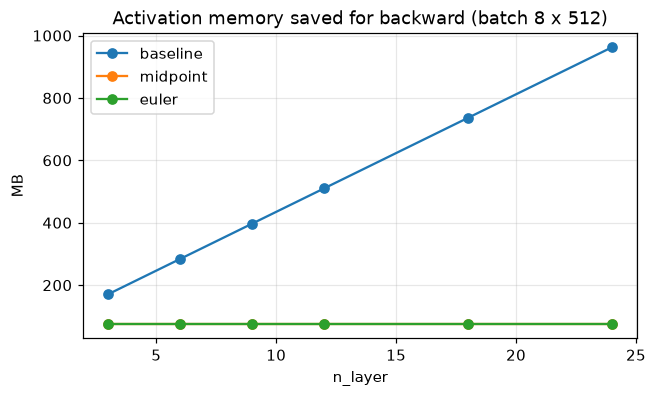

**Marginal activation memory per extra layer** (batch 8): baseline: **37.7 MB/layer**, midpoint: **0.0 MB/layer**, euler: **0.0 MB/layer**

In [11]:
def saved_activation_mb(variant, n_layer, batch=8):
    cfg = GPTConfig(
        vocab_size=data.vocab_size,
        block_size=BLOCK_SIZE,
        variant=variant,
        n_layer=n_layer,
        n_head=MODEL["n_head"],
        n_embd=MODEL["n_embd"],
        loss_chunk_size=LOSS_CHUNK,
    )
    model = build_model(cfg, device=DEVICE)
    x = torch.randint(0, cfg.vocab_size, (batch, BLOCK_SIZE), device=DEVICE)
    torch.cuda.synchronize(DEVICE)
    before = torch.cuda.memory_allocated(DEVICE)
    with torch.autocast("cuda", dtype=torch.bfloat16):
        _, loss, _ = model(x, x)
    saved = (torch.cuda.memory_allocated(DEVICE) - before) / 2**20
    loss.backward()
    del model, x, loss
    torch.cuda.empty_cache()
    return saved


if IS_CUDA:
    depths = [3, 6, 9, 12, 18, 24]
    depth_df = pd.DataFrame(
        {
            v: [saved_activation_mb(v, L) for L in depths]
            for v in ["baseline", "midpoint", "euler"]
        },
        index=pd.Index(depths, name="n_layer"),
    )
    display(depth_df.round(1))
    ax = depth_df.plot(
        marker="o",
        figsize=(6.5, 3.6),
        title="Activation memory saved for backward (batch 8 x 512)",
    )
    ax.set_ylabel("MB")
    plt.show()
    growth = {
        v: (depth_df[v].iloc[-1] - depth_df[v].iloc[0]) / (depths[-1] - depths[0])
        for v in depth_df
    }
    display(
        Markdown(
            "**Marginal activation memory per extra layer** (batch 8): "
            + ", ".join(f"{v}: **{g:.1f} MB/layer**" for v, g in growth.items())
        )
    )

**Observed.** This is the core claim of the paper, measured directly. The baseline stores **37.7 MB more per layer** at batch 8 (171 MB at 3 layers → 963 MB at 24), so it is exactly linear in depth. Both reversible stacks store a constant **74 MB from 3 to 24 layers**: the final pair of float64 streams, the embedding input, and the 49 MB batch-independent fused-loss buffer. At 24 layers that is already a 13x difference, and it keeps growing with depth.

## 5. Choosing the batch size `x`

`x` has to satisfy three constraints on a ~40 GB GPU:

1. **All three variants fit at `x`**, which the baseline needs for experiments 1-3.
2. **Both reversible variants fit at `8x`.** The winner is not known yet and it must fit at experiment 6.
3. **Enough optimizer steps remain at `8x`.** The token budget is fixed at 50M, so `8x` gets 1/8 of the steps. At `x = 128` (65,536 tokens per step) that is 763 steps at `x` and 96 at `8x`. At `x = 256` it would be only 48 steps at `8x`, too few for a meaningful LR schedule.

Local measurements put the baseline at ~42 MB of saved activations per 512-token sequence and the reversible variants at ~2 MB. On 40 GB the baseline should therefore top out around batch 800-900, while `x = 128` puts `8x = 1024` beyond what the baseline can fit but well within the reversible budget. The probe below verifies this on *this* GPU with real training steps (forward, backward, AdamW). An `OOM` in the baseline column at `8x` is the expected outcome, and it is the point of the exercise.

In [12]:
probe_batches = sorted(
    {max(1, BATCH_X // 2), BATCH_X, 2 * BATCH_X, 4 * BATCH_X, 8 * BATCH_X}
)
probe_rows = []
if IS_CUDA:
    for variant in ["baseline", "midpoint", "euler"]:
        cfg = GPTConfig(
            vocab_size=data.vocab_size,
            block_size=BLOCK_SIZE,
            variant=variant,
            loss_chunk_size=LOSS_CHUNK,
            **MODEL,
        )
        for b in probe_batches:
            probe_rows.append(probe_step(cfg, b, DEVICE, steps=2))
probe_df = pd.DataFrame(probe_rows)
if len(probe_df):
    mem_table = probe_df.pivot(
        index="batch_size", columns="variant", values="peak_memory_mb"
    )[["baseline", "midpoint", "euler"]]
    act_table = probe_df.pivot(
        index="batch_size", columns="variant", values="activation_saved_mb_per_sample"
    )[["baseline", "midpoint", "euler"]]
    tps_table = probe_df.pivot(
        index="batch_size", columns="variant", values="tokens_per_sec"
    )[["baseline", "midpoint", "euler"]]
    display(Markdown("**Peak memory per training step (MB)**. Blank means OOM."))
    display(mem_table.round(0))
    display(Markdown("**Activation memory saved for backward, per sequence (MB)**"))
    display(act_table.round(2))
    display(Markdown("**Probe throughput (tokens/s, median of 2 steps, rough)**"))
    display(tps_table.round(0))

**Peak memory per training step (MB)**. Blank means OOM.

variant,baseline,midpoint,euler
batch_size,,,
64,6951.0,4474.0,4474.0
128,9653.0,4698.0,4698.0
256,15057.0,5147.0,5147.0
512,25865.0,8908.0,8524.0
1024,NaN,17498.0,16728.0


**Activation memory saved for backward, per sequence (MB)**

variant,baseline,midpoint,euler
batch_size,,,
64,41.93,3.0,3.0
128,41.82,3.0,3.0
256,41.77,3.0,3.0
512,41.74,3.0,3.0
1024,NaN,3.0,3.0


**Probe throughput (tokens/s, median of 2 steps, rough)**

variant,baseline,midpoint,euler
batch_size,,,
64,157883.0,131600.0,119152.0
128,168514.0,135027.0,122273.0
256,170196.0,136450.0,123590.0
512,170027.0,136262.0,123404.0
1024,NaN,136609.0,123856.0


In [13]:
def fits(variant, batch):
    row = probe_df[(probe_df.variant == variant) & (probe_df.batch_size == batch)]
    return bool(len(row)) and bool(row.fits.iloc[0])


if IS_CUDA:
    checks = {
        f"baseline fits x={BATCH_X}": fits("baseline", BATCH_X),
        f"midpoint fits 8x={8 * BATCH_X}": fits("midpoint", 8 * BATCH_X),
        f"euler fits 8x={8 * BATCH_X}": fits("euler", 8 * BATCH_X),
        f"baseline fits 8x={8 * BATCH_X} (expected False on 40 GB)": fits(
            "baseline", 8 * BATCH_X
        ),
    }
    display(pd.Series(checks, name="result").to_frame())
    assert checks[f"baseline fits x={BATCH_X}"], (
        "x too large for the baseline on this GPU: lower BATCH_X in the configuration cell"
    )
    assert (
        checks[f"midpoint fits 8x={8 * BATCH_X}"]
        and checks[f"euler fits 8x={8 * BATCH_X}"]
    ), "8x does not fit a reversible variant: lower BATCH_X in the configuration cell"

schedule = pd.DataFrame(
    [
        {
            "experiment": name,
            "batch": b,
            "tokens/step": b * BLOCK_SIZE,
            "optimizer steps": math.ceil(TOKEN_BUDGET / (b * BLOCK_SIZE)),
        }
        for name, b in [
            ("1-3 (x)", BATCH_X),
            ("4 (2x)", 2 * BATCH_X),
            ("5 (4x)", 4 * BATCH_X),
            ("6 (8x)", 8 * BATCH_X),
        ]
    ]
)
display(schedule)

,result
baseline fits x=128,True
midpoint fits 8x=1024,True
euler fits 8x=1024,True
baseline fits 8x=1024 (expected False on 40 GB),False


,experiment,batch,tokens/step,optimizer steps
0,1-3 (x),128,65536,763
1,4 (2x),256,131072,382
2,5 (4x),512,262144,191
3,6 (8x),1024,524288,96


**Observed.** The probe confirmed the choice of `x = 128` on the 48 GB RTX A6000:

* **Stored activations are exactly as predicted:** 41.8 MB per sequence for the baseline and 3.0 MB for both reversible variants, constant across batch sizes.
* **Peak memory at batch 128** is 9.43 GB for the baseline against 4.59 GB for either reversible variant (probe; the training runs measured 9.45 and 4.61 GB). At batch 512 it is 25.3 GB against 8.3-8.7 GB.
* **At batch 1024 (8x) the baseline runs out of memory**, while midpoint and Euler fit in 17.1 and 16.3 GB. The assignment's scale-up is therefore only possible with the reversible model.
* **Throughput is already flat from batch 128 upward** for every variant (baseline 168-170k tokens/s, midpoint ~136k, Euler ~123k). This predicts experiments 4-6: larger batches will not buy much speed on this GPU.

## 6. Training protocol

| setting | value | notes |
|---|---|---|
| optimizer | AdamW (fused), betas (0.9, 0.95), wd 0.1 on matrices only | |
| peak LR at `x` | 1e-3 | a small-model value; a local sweep beat 3e-4 by a wide margin at this step count |
| schedule | linear warmup (5% of steps, min 10), cosine decay to 10% of peak | warmup and decay scale with each run's step count |
| LR at `2x`/`4x`/`8x` | **sqrt scaling**: `lr = 1e-3 * sqrt(batch / x)`, capped at 3e-3 | the standard Adam heuristic; see note below |
| grad clipping | global norm 1.0 | |
| precision | bf16 autocast, fp32 master weights and residual streams | |
| loss | fused chunked lm_head + cross-entropy (no full logits tensor) | same for every variant |
| dropout | 0 | reversible cells forbid dropout (the recompute would draw different masks) |
| midpoint step size | h = 0.25 (2h = 0.5) | best of h in {1/9, 0.25, 0.5} in a local sweep (below) |
| reversible streams | float64 fixed-point, exact reversal | Section 4.3, item 4 |
| seed | 1337 | same data order for every run |

**Why scale the LR for experiments 4-6?** At a fixed token budget, `8x` batch means 8x fewer optimizer steps. Keeping the LR fixed would confound "bigger batch" with "much less optimization". sqrt(k) scaling keeps the per-step noise-to-signal ratio roughly constant for Adam, so the comparison stays fair to the large-batch runs. Experiments 1-3 all use exactly the same LR, schedule and data order, which is what isolates the architecture.

**Preliminary local sweep behind the LR and h choices.** Measured on the development machine: an RTX 500 Ada 4 GB laptop GPU, WikiText-2, batch 16, 2M tokens, one seed. These numbers only justify the settings. They are *not* results of this assignment.

| run | streams | final val loss | tokens/s | recon drift at input | grad rel. error vs autograd |
|---|---|---|---|---|---|
| baseline, lr 3e-4 | - | 6.573 | 32.1k | - | - |
| **baseline, lr 1e-3** | - | **6.266** | 32.0k | - | - |
| midpoint h = 1/9 (previous default) | fp32 | 6.289 | 29.0k | 0.023 | 0.16% |
| midpoint h = 0.25 | fp32 | 6.260 | 28.8k | 0.084 | 0.25% |
| midpoint h = 0.5 | fp32 | 6.271 | 29.1k | 0.253 | 0.41% |
| Euler | fp32 | 6.300 | 29.4k | 0.112 | 1.98% |
| **midpoint h = 0.25** | **exact fp64** | **6.261** | 24.8k | **0** | 0.00% |
| midpoint h = 0.5 | exact fp64 | 6.270 | 24.8k | 0 | 0.04% |
| Euler | exact fp64 | 6.304 | 21.8k | 0 | 0.06% |

Takeaways: lr 1e-3 is far better than 3e-4 at this step count. Among midpoint step sizes, larger h drifts more (the paper's stability analysis), and h = 0.25 has the lowest loss. Exact streams remove drift completely at the same loss. On this laptop GPU (fp64 at 1/64 rate) exact mode costs 15-25% throughput; the Section 4.4 timing cell measures the cost on the real GPU.

In [14]:
def make_config(variant, batch_size, label, lr_scaling="none"):
    return TrainConfig(
        variant=variant,
        batch_size=batch_size,
        block_size=BLOCK_SIZE,
        token_budget=TOKEN_BUDGET,
        learning_rate=BASE_LR,
        lr_scaling=lr_scaling,
        lr_ref_batch=BATCH_X,
        max_lr=MAX_LR,
        midpoint_h=MIDPOINT_H,
        reversible_exact=REVERSIBLE_EXACT,
        seed=SEED,
        loss_chunk_size=LOSS_CHUNK,
        device=DEVICE,
        aim_repo=AIM_REPO,
        experiment=EXPERIMENT,
        label=label,
        **EVAL,
        **MODEL,
    )


preview = pd.DataFrame(
    [
        {
            "label": lbl,
            "batch": c.batch_size,
            "steps": c.total_steps,
            "warmup": c.warmup_steps,
            "peak_lr": c.peak_lr,
            "eval every (steps)": c.eval_every_steps,
        }
        for lbl, c in [
            (l, make_config("midpoint", b, l, s))
            for l, b, s in [
                ("x", BATCH_X, "none"),
                ("2x", 2 * BATCH_X, LR_SCALING_FOR_SCALE_UP),
                ("4x", 4 * BATCH_X, LR_SCALING_FOR_SCALE_UP),
                ("8x", 8 * BATCH_X, LR_SCALING_FOR_SCALE_UP),
            ]
        ]
    ]
)
display(preview)

,label,batch,steps,warmup,peak_lr,eval every (steps)
0,x,128,763,38,0.001000,38
1,2x,256,382,19,0.001414,19
2,4x,512,191,10,0.002000,10
3,8x,1024,96,10,0.002828,5


## 7. Analysis helpers

These are defined here rather than in `src/` because they are the notebook's reporting layer. Every experiment below runs the trainer, then:

* `metrics_table`: a one-column table of every summary metric, grouped as quality, speed, compute, memory and optimization.
* `plot_run`: an 8-panel dashboard (loss vs tokens, accuracy, LR, grad norm, throughput, step-time breakdown, memory timeline, per-step peak).
* `findings`: data-driven observations, including deltas against a reference run.

`run_or_load` skips training when a finished result already exists and `REUSE_RESULTS = True`, so an interrupted notebook can be re-executed without redoing completed runs.

In [15]:
RECORDS: dict[str, dict] = {}


def run_or_load(variant, batch_size, label, lr_scaling="none"):
    cfg = make_config(variant, batch_size, label, lr_scaling)
    cached = load_record(label, RESULTS_DIR) if REUSE_RESULTS else None
    if (
        cached
        and cached["summary"]["status"] == "ok"
        and cached["config"]["token_budget"] == TOKEN_BUDGET
    ):
        print(f"[reuse] {label}: loaded {RESULTS_DIR / (label + '.json')}")
        record = cached
    else:
        print(
            f"[train] {label}: variant={variant} batch={batch_size} steps={cfg.total_steps} peak_lr={cfg.peak_lr:.2e}"
        )
        record = train(data, cfg, results_dir=RESULTS_DIR, log_dir=LOG_DIR)
    RECORDS[label] = record
    s = record["summary"]
    print(
        f"status={s['status']}  log={LOG_DIR / (label + '.log')}  aim_run={s.get('aim_run_hash')}"
    )
    return record


SECTIONS = {
    "quality": [
        "final_val_loss",
        "final_val_perplexity",
        "final_val_accuracy",
        "final_train_loss",
        "final_train_accuracy",
        "generalization_gap",
        "best_periodic_val_loss",
        "tokens_to_val_loss_6",
        "tokens_to_val_loss_5",
        "tokens_to_val_loss_4.5",
    ],
    "speed": [
        "mean_tokens_per_sec",
        "median_tokens_per_sec",
        "p10_tokens_per_sec",
        "p90_tokens_per_sec",
        "mean_step_time_ms",
        "mean_data_ms",
        "mean_forward_ms",
        "mean_backward_ms",
        "mean_optimizer_ms",
        "train_time_s",
        "eval_time_s",
        "wall_clock_s",
    ],
    "compute": [
        "model_tflops_per_sec",
        "hardware_tflops_per_sec",
        "mfu",
        "hfu",
        "total_model_pflops",
        "model_flops_per_token",
        "hardware_flops_per_token",
    ],
    "memory": [
        "peak_step_memory_mb",
        "peak_memory_reserved_mb",
        "static_memory_mb",
        "param_memory_mb",
        "optimizer_state_mb",
        "activation_saved_mb",
        "activation_saved_mb_per_sample",
        "peak_memory_frac_of_gpu",
    ],
    "optimization": [
        "batch_size",
        "total_steps",
        "tokens_seen",
        "peak_lr",
        "warmup_steps",
        "mean_grad_norm",
        "max_grad_norm",
        "frac_steps_clipped",
    ],
}


def metrics_table(*labels):
    rows = []
    for section, keys in SECTIONS.items():
        for key in keys:
            rows.append(
                {
                    "section": section,
                    "metric": key,
                    **{lbl: RECORDS[lbl]["summary"].get(key) for lbl in labels},
                }
            )
    return pd.DataFrame(rows).set_index(["section", "metric"])


def plot_run(label, ref_label=None):
    rec = RECORDS[label]
    h, e = rec["history"], rec["evals"]
    ref = RECORDS.get(ref_label) if ref_label else None
    fig, ax = plt.subplots(2, 4, figsize=(19, 7.2))
    tok_m = np.array(h["tokens"]) / 1e6
    ax[0, 0].plot(tok_m, h["loss"], alpha=0.35, lw=0.8, label="train (per step)")
    ax[0, 0].plot(
        np.array(e["tokens"]) / 1e6, e["train_loss"], "o-", label="train (eval)"
    )
    ax[0, 0].plot(np.array(e["tokens"]) / 1e6, e["val_loss"], "s-", label="val (eval)")
    if ref:
        ax[0, 0].plot(
            np.array(ref["evals"]["tokens"]) / 1e6,
            ref["evals"]["val_loss"],
            "k--",
            lw=1,
            label=f"val: {ref_label}",
        )
    ax[0, 0].set(
        title="loss",
        xlabel="tokens (M)",
        ylim=(min(e["val_loss"]) - 0.3, min(8.0, max(e["val_loss"][1:] or [8]) + 0.3)),
    )
    ax[0, 0].legend(fontsize=7)
    ax[0, 1].plot(np.array(e["tokens"]) / 1e6, e["train_accuracy"], "o-", label="train")
    ax[0, 1].plot(np.array(e["tokens"]) / 1e6, e["val_accuracy"], "s-", label="val")
    if ref:
        ax[0, 1].plot(
            np.array(ref["evals"]["tokens"]) / 1e6,
            ref["evals"]["val_accuracy"],
            "k--",
            lw=1,
            label=f"val: {ref_label}",
        )
    ax[0, 1].set(title="next-token accuracy", xlabel="tokens (M)")
    ax[0, 1].legend(fontsize=7)
    ax[0, 2].plot(h["step"], h["lr"])
    ax[0, 2].set(title="learning rate", xlabel="step")
    ax[0, 3].plot(h["step"], h["grad_norm"], lw=0.8)
    ax[0, 3].axhline(1.0, color="r", ls=":", lw=1)
    ax[0, 3].set(title="grad norm (clip = 1.0)", xlabel="step", yscale="log")
    ax[1, 0].plot(h["step"], h["tokens_per_sec"], lw=0.8, label=label)
    if ref:
        ax[1, 0].axhline(
            ref["summary"]["mean_tokens_per_sec"],
            color="k",
            ls="--",
            lw=1,
            label=f"{ref_label} mean",
        )
    ax[1, 0].set(title="throughput (tokens/s)", xlabel="step")
    ax[1, 0].legend(fontsize=7)
    parts = ["data_ms", "forward_ms", "backward_ms", "optimizer_ms"]
    means = [
        rec["summary"].get(f"mean_{p}") or 0
        for p in ["data_ms", "forward_ms", "backward_ms", "optimizer_ms"]
    ]
    bars = {label: means}
    if ref:
        bars[ref_label] = [
            ref["summary"].get(f"mean_{p}") or 0
            for p in ["data_ms", "forward_ms", "backward_ms", "optimizer_ms"]
        ]
    bottom = np.zeros(len(bars))
    for i, p in enumerate(parts):
        vals = np.array([v[i] for v in bars.values()])
        ax[1, 1].bar(list(bars), vals, bottom=bottom, label=p.replace("_ms", ""))
        bottom += vals
    ax[1, 1].set(title="mean step-time breakdown (ms)")
    ax[1, 1].legend(fontsize=7)
    ax[1, 2].plot(h["step"], h["memory_allocated_mb"], label="allocated after step")
    ax[1, 2].plot(h["step"], h["memory_reserved_mb"], label="reserved")
    ax[1, 2].plot(h["step"], h["activation_saved_mb"], label="saved activations")
    ax[1, 2].set(title="memory (MB)", xlabel="step")
    ax[1, 2].legend(fontsize=7)
    ax[1, 3].plot(h["step"], h["step_peak_memory_mb"], label=label)
    if ref:
        ax[1, 3].axhline(
            ref["summary"]["peak_step_memory_mb"],
            color="k",
            ls="--",
            lw=1,
            label=f"{ref_label}",
        )
    ax[1, 3].set(title="per-step peak memory (MB)", xlabel="step")
    ax[1, 3].legend(fontsize=7)
    fig.suptitle(
        f"{label}: {rec['summary']['variant']}, batch {rec['summary']['batch_size']}",
        fontsize=13,
    )
    fig.tight_layout()
    plt.show()


def _pct(a, b):
    return (a / b - 1) * 100 if a is not None and b else float("nan")


def findings(label, ref_label=None):
    s = RECORDS[label]["summary"]
    e = RECORDS[label]["evals"]
    if s["status"] != "ok":
        display(
            Markdown(
                f"### Findings: `{label}`\n\n**Run did not finish: status `{s['status']}`** ({s['error']})."
            )
        )
        return
    out = [f"### Findings: `{label}`", ""]
    out.append(
        f"- **Quality:** final val loss **{s['final_val_loss']:.4f}** (perplexity {s['final_val_perplexity']:.1f}), "
        f"val accuracy **{s['final_val_accuracy'] * 100:.2f}%**; train loss {s['final_train_loss']:.4f}, "
        f"generalization gap {s['generalization_gap']:+.4f}."
    )
    if len(e["val_loss"]) >= 3:
        last_drop = e["val_loss"][-2] - e["val_loss"][-1]
        span = (e["tokens"][-1] - e["tokens"][-2]) / 1e6
        if last_drop > 0.01:
            trend = f"fell {last_drop:.4f} over the last {span:.2f}M tokens and was still improving, so the model is budget-limited"
        elif last_drop >= 0:
            trend = f"moved only {last_drop:.4f} over the last {span:.2f}M tokens and had flattened"
        else:
            trend = f"**rose** {-last_drop:.4f} over the last {span:.2f}M tokens, a sign of an unstable or too-aggressive LR schedule"
        out.append(f"- **Convergence:** val loss {trend}.")
    out.append(
        f"- **Speed:** {s['mean_tokens_per_sec']:,.0f} tokens/s (p10-p90: {s['p10_tokens_per_sec']:,.0f} to {s['p90_tokens_per_sec']:,.0f}); "
        f"step {s['mean_step_time_ms']:.1f} ms = data {s['mean_data_ms']:.1f} + forward {s['mean_forward_ms'] or 0:.1f} "
        f"+ backward {s['mean_backward_ms'] or 0:.1f} + optimizer {s['mean_optimizer_ms'] or 0:.1f} ms; wall clock {s['wall_clock_s'] / 60:.1f} min. "
        f"(Forward includes the fused lm_head gradient, see Section 3.)"
    )
    mfu = (
        f"MFU **{s['mfu'] * 100:.1f}%**, HFU {s['hfu'] * 100:.1f}%"
        if s.get("mfu")
        else "MFU n/a (unknown GPU peak)"
    )
    out.append(
        f"- **Compute:** {s['model_tflops_per_sec']:.1f} model TFLOP/s ({s['hardware_tflops_per_sec']:.1f} hardware TFLOP/s incl. recompute); {mfu}; "
        f"{s['total_model_pflops']:.3g} PFLOP total."
    )
    out.append(
        f"- **Memory:** per-step peak **{s['peak_step_memory_mb']:,.0f} MB**"
        + (
            f" ({s['peak_memory_frac_of_gpu'] * 100:.1f}% of the GPU)"
            if s.get("peak_memory_frac_of_gpu")
            else ""
        )
        + f"; static {s['static_memory_mb']:,.0f} MB (params {s['param_memory_mb']:,.0f} + AdamW {s['optimizer_state_mb']:,.0f}); "
        f"activations saved for backward **{s['activation_saved_mb']:,.0f} MB** (of which {s['loss_buffer_mb']:.0f} MB is the batch-independent fused-loss "
        f"weight-gradient buffer) = **{s['activation_saved_mb_per_sample']:.2f} MB per sequence**."
    )
    out.append(
        f"- **Optimization:** {s['total_steps']} steps, peak LR {s['peak_lr']:.2e}, mean grad norm {s['mean_grad_norm']:.3f} "
        f"(max {s['max_grad_norm']:.2f}), clipped on {s['frac_steps_clipped'] * 100:.1f}% of steps."
    )
    if s.get("reversibility"):
        r = s["reversibility"]
        out.append(
            f"- **Reversibility (trained weights, bf16):** max reconstruction drift {r['max_rel_error']:.2e} "
            f"(at the input: {r['input_rel_error']:.2e}); gradient vs plain autograd: cosine {r['grad_cosine']:.6f}, "
            f"relative error {r['grad_rel_error']:.2e}."
        )
    if (
        ref_label
        and ref_label in RECORDS
        and RECORDS[ref_label]["summary"]["status"] == "ok"
    ):
        r = RECORDS[ref_label]["summary"]
        out.append("")
        out.append(
            f"**Compared to `{ref_label}`:** val loss {s['final_val_loss'] - r['final_val_loss']:+.4f} "
            f"({_pct(s['final_val_loss'], r['final_val_loss']):+.2f}%), val accuracy "
            f"{(s['final_val_accuracy'] - r['final_val_accuracy']) * 100:+.2f} pts, throughput "
            f"**{_pct(s['mean_tokens_per_sec'], r['mean_tokens_per_sec']):+.1f}%**, wall clock "
            f"{_pct(s['wall_clock_s'], r['wall_clock_s']):+.1f}%, per-step peak memory "
            f"**{_pct(s['peak_step_memory_mb'], r['peak_step_memory_mb']):+.1f}%**, activation memory per sequence "
            f"**{r['activation_saved_mb_per_sample'] / s['activation_saved_mb_per_sample']:.1f}x smaller**"
            if s["activation_saved_mb_per_sample"]
            else ""
        )
    display(Markdown("\n".join(out)))


def report(label, ref_label=None):
    display(
        metrics_table(*[l for l in [label, ref_label] if l]).style.format(
            lambda v: (
                f"{v:,.4f}"
                if isinstance(v, float) and abs(v) < 100
                else (f"{v:,.0f}" if isinstance(v, (int, float)) else v)
            ),
            na_rep="-",
        )
    )
    if RECORDS[label]["summary"]["status"] == "ok":
        plot_run(label, ref_label)
    findings(label, ref_label)

---
## Experiment 1: Baseline, batch size `x`

The standard pre-LN transformer, trained on 50M tokens at batch `x`. It is the reference point for everything else.

**Expectations.** Activation memory grows with depth and batch, ~42 MB per 512-token sequence (Section 5). Throughput is the highest of the three variants because nothing is recomputed. Val loss should still be falling at the end of the budget: a 20M model is nowhere near converged after 50M tokens.

[train] exp1_baseline_x: variant=baseline batch=128 steps=763 peak_lr=1.00e-03


exp1_baseline_x:   0%|          | 0/763 [00:00<?, ?it/s]

status=ok  log=/home/ravi.naik/learning/era/ERA/v5/session13/reversible_llm_experiments/notebooks/logs/exp1_baseline_x.log  aim_run=1c5bbaf63b394c7ab66783bc


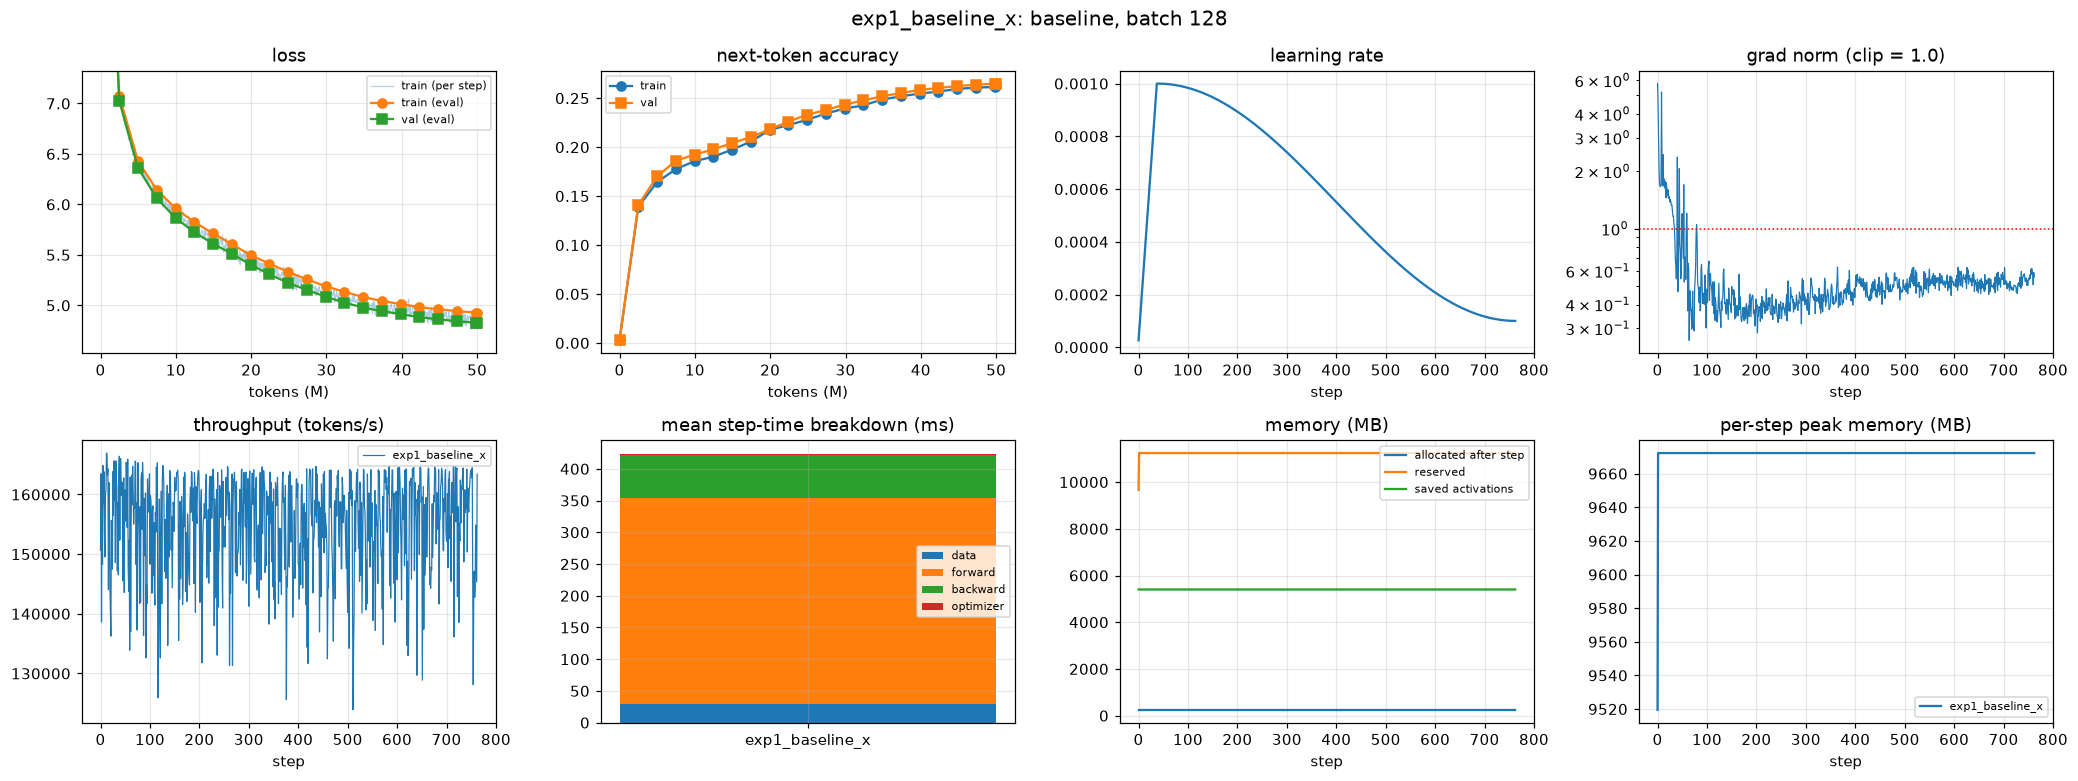

### Findings: `exp1_baseline_x`

- **Quality:** final val loss **4.8279** (perplexity 124.9), val accuracy **26.75%**; train loss 4.8715, generalization gap -0.0437.
- **Convergence:** val loss moved only 0.0015 over the last 0.20M tokens and had flattened.
- **Speed:** 154,834 tokens/s (p10-p90: 142,789 to 163,992); step 424.6 ms = data 29.3 + forward 325.4 + backward 66.6 + optimizer 2.6 ms; wall clock 5.9 min. (Forward includes the fused lm_head gradient, see Section 3.)
- **Compute:** 20.7 model TFLOP/s (20.7 hardware TFLOP/s incl. recompute); MFU **13.4%**, HFU 13.4%; 6.69 PFLOP total.
- **Memory:** per-step peak **9,672 MB** (19.9% of the GPU); static 251 MB (params 78 + AdamW 155); activations saved for backward **5,402 MB** (of which 49 MB is the batch-independent fused-loss weight-gradient buffer) = **41.82 MB per sequence**.
- **Optimization:** 763 steps, peak LR 1.00e-03, mean grad norm 0.554 (max 5.76), clipped on 5.5% of steps.

In [16]:
LBL_BASE = "exp1_baseline_x"
run_or_load("baseline", BATCH_X, LBL_BASE)
report(LBL_BASE)

### Observed: experiment 1 (baseline)

* **Quality:** val loss **4.828** (perplexity 124.9, next-token accuracy 26.75%). The loss was still falling at the end (−0.015 over the last 2.5M tokens), so the model is budget-limited, as expected for 50M tokens at 20M parameters (~2.5 tokens per parameter). Val loss is 0.044 *below* train loss: at 0.42 epochs nothing is memorized, and the validation split is slightly easier text.
* **Speed:** **154.8k tokens/s** at 13.4% MFU (RTX A6000 bf16 peak: 154.8 TFLOP/s). The low MFU has a clear cause. 77% of the step is the "forward" phase, which includes the fused 50,257-way vocab projection and its gradient. That projection is 58% of the model's FLOPs and runs memory-bandwidth-bound on the (tokens x vocab) softmax. Data loading takes 29 ms (7%) per step.
* **Memory:** peak **9.45 GB**, of which 5.28 GB are activations stored for backward (41.8 MB per sequence). The parameters and AdamW state are only 0.25 GB. At this scale, activations *are* the memory problem, which is exactly what reversibility targets.
* **Stability:** mean gradient norm 0.55, clipped on 5.5% of steps (41 of those 42 steps fall in the first 80 steps, i.e. warmup), no loss spikes.

---
## Experiment 2: Reversible midpoint, batch size `x`

Same data order, batch size, LR schedule and token budget. Only the depth recurrence changes, to $p^{(\ell+1)} = p^{(\ell-1)} + 2h f_\ell(p^{(\ell)})$ with $h=0.25$, backpropagated with the O(1)-memory reversible backward.

**Expectations.** Much smaller saved activations (~2 MB per sequence rather than ~42), at the cost of recomputing the backbone in backward: throughput a few percent to ~15% lower than the baseline, with the loss-dominated step time masking part of it. Loss should be close to the baseline (the paper reports midpoint within ~0.01 of baseline for GPT-2). Because reversal is exact, the diagnostics at the end of the run should show zero reconstruction drift even though the midpoint scheme is only marginally stable.

[train] exp2_midpoint_x: variant=midpoint batch=128 steps=763 peak_lr=1.00e-03


exp2_midpoint_x:   0%|          | 0/763 [00:00<?, ?it/s]

status=ok  log=/home/ravi.naik/learning/era/ERA/v5/session13/reversible_llm_experiments/notebooks/logs/exp2_midpoint_x.log  aim_run=464874f7bb0f4192b3c75c9d


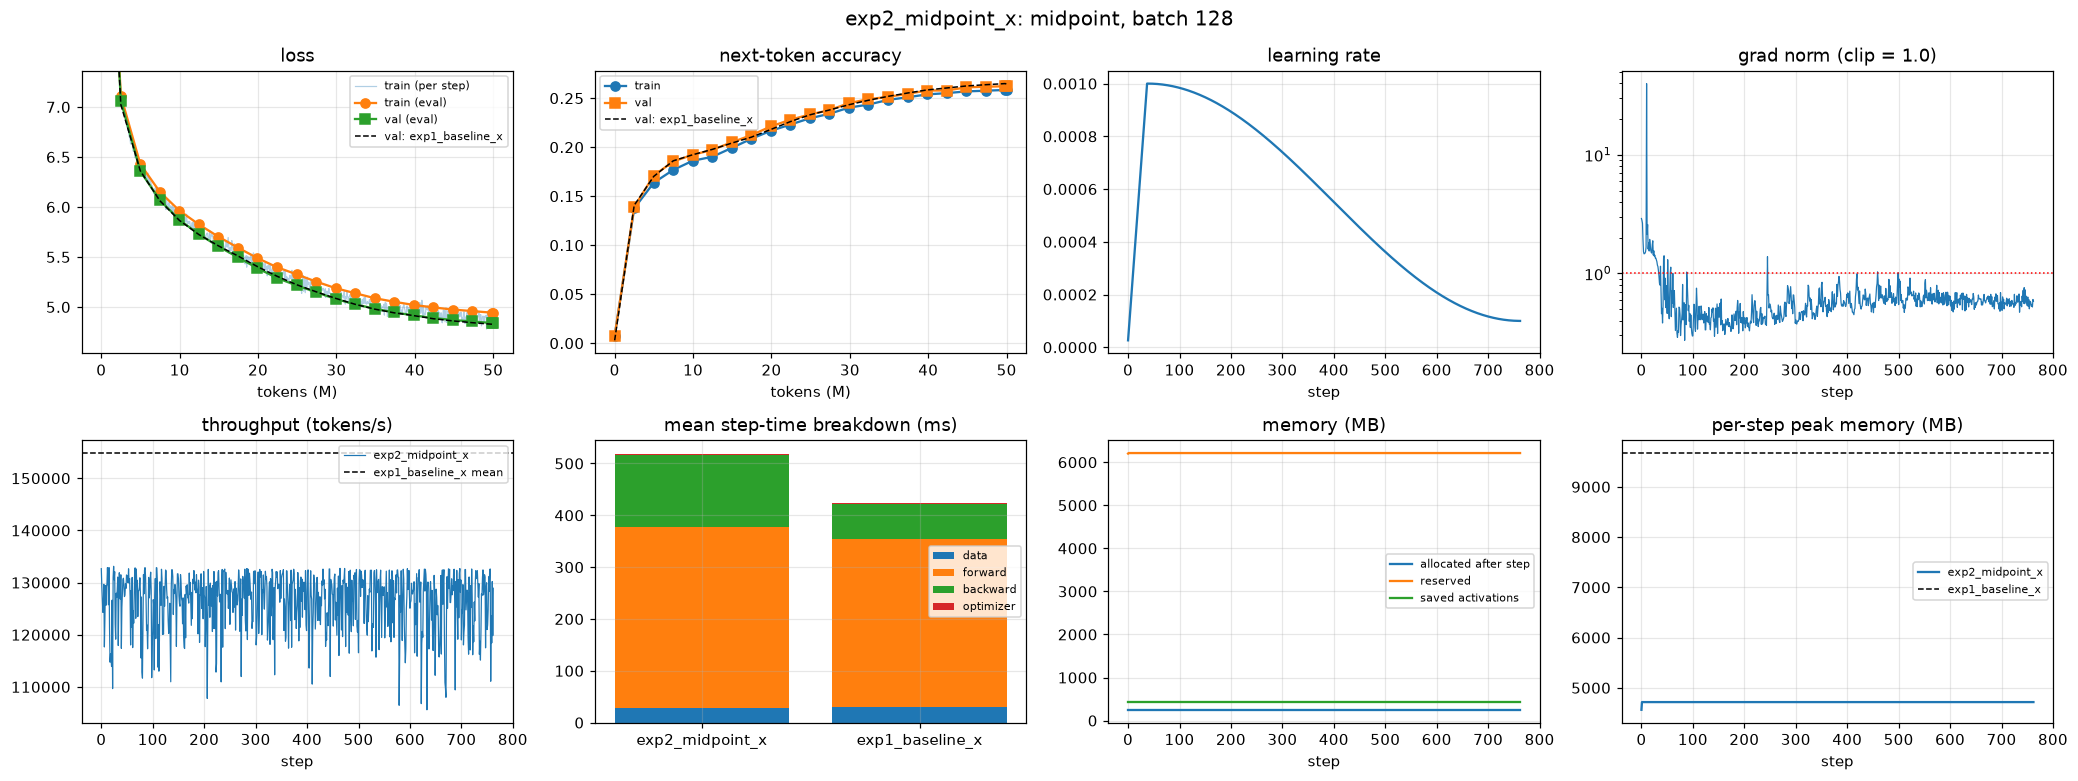

### Findings: `exp2_midpoint_x`

- **Quality:** final val loss **4.8420** (perplexity 126.7), val accuracy **26.46%**; train loss 4.8855, generalization gap -0.0435.
- **Convergence:** val loss moved only 0.0016 over the last 0.20M tokens and had flattened.
- **Speed:** 126,371 tokens/s (p10-p90: 118,757 to 132,271); step 519.6 ms = data 28.2 + forward 349.6 + backward 138.6 + optimizer 2.6 ms; wall clock 7.1 min. (Forward includes the fused lm_head gradient, see Section 3.)
- **Compute:** 16.9 model TFLOP/s (19.3 hardware TFLOP/s incl. recompute); MFU **10.9%**, HFU 12.5%; 6.69 PFLOP total.
- **Memory:** per-step peak **4,716 MB** (9.7% of the GPU); static 250 MB (params 78 + AdamW 154); activations saved for backward **434 MB** (of which 49 MB is the batch-independent fused-loss weight-gradient buffer) = **3.00 MB per sequence**.
- **Optimization:** 763 steps, peak LR 1.00e-03, mean grad norm 0.658 (max 39.85), clipped on 5.8% of steps.
- **Reversibility (trained weights, bf16):** max reconstruction drift 0.00e+00 (at the input: 0.00e+00); gradient vs plain autograd: cosine 1.000000, relative error 8.83e-04.

**Compared to `exp1_baseline_x`:** val loss +0.0141 (+0.29%), val accuracy -0.29 pts, throughput **-18.4%**, wall clock +19.6%, per-step peak memory **-51.2%**, activation memory per sequence **13.9x smaller**

In [17]:
LBL_MID = "exp2_midpoint_x"
run_or_load("midpoint", BATCH_X, LBL_MID)
report(LBL_MID, LBL_BASE)

### Observed: experiment 2 (reversible midpoint)

* **Memory, as predicted:** peak **4.61 GB (−51%)**, stored activations 0.42 GB (3.0 MB per sequence, **14x less**). Reconstruction error was exactly 0 on the trained weights, and gradient cosine vs autograd 0.9999996.
* **Quality, as predicted:** val loss **4.842 (+0.014 vs baseline)**. The curve tracks the baseline within ±0.02 for the whole run: slightly ahead from 15-25M tokens, slightly behind at the end. This matches the paper's report that midpoint lands within ~0.01 of the baseline.
* **Speed, worse than predicted:** **126.4k tokens/s (−18.4%)**, against the ~14% extra FLOPs the recompute adds. Backward takes 139 ms instead of 67 ms, and forward is 7% slower because of the float64 streams. The Section 4.4 probe accounts for the gap: exact reversal adds ~13% to midpoint's step time on this GPU; with plain fp32 streams, midpoint would be ~10% slower than the baseline.

---
## Experiment 3: Reversible Euler, batch size `x`

The two-stream symplectic-Euler (Hamiltonian) update: attention updates $q$ from $p$, then the MLP updates $p$ from the new $q$.

**Expectations.** Memory is the same as midpoint: both store two float64 streams (midpoint keeps the current and previous state, Euler keeps q and p), and both are O(1) in depth. Compute and recompute are also the same. The architecture is less like a standard transformer (attention and MLP see different streams, and every layer's attention reads a state that has not yet seen that layer's MLP), so loss may be slightly worse than the baseline.

[train] exp3_euler_x: variant=euler batch=128 steps=763 peak_lr=1.00e-03


exp3_euler_x:   0%|          | 0/763 [00:00<?, ?it/s]

status=ok  log=/home/ravi.naik/learning/era/ERA/v5/session13/reversible_llm_experiments/notebooks/logs/exp3_euler_x.log  aim_run=0c54998f0c674c23b74f6a7a


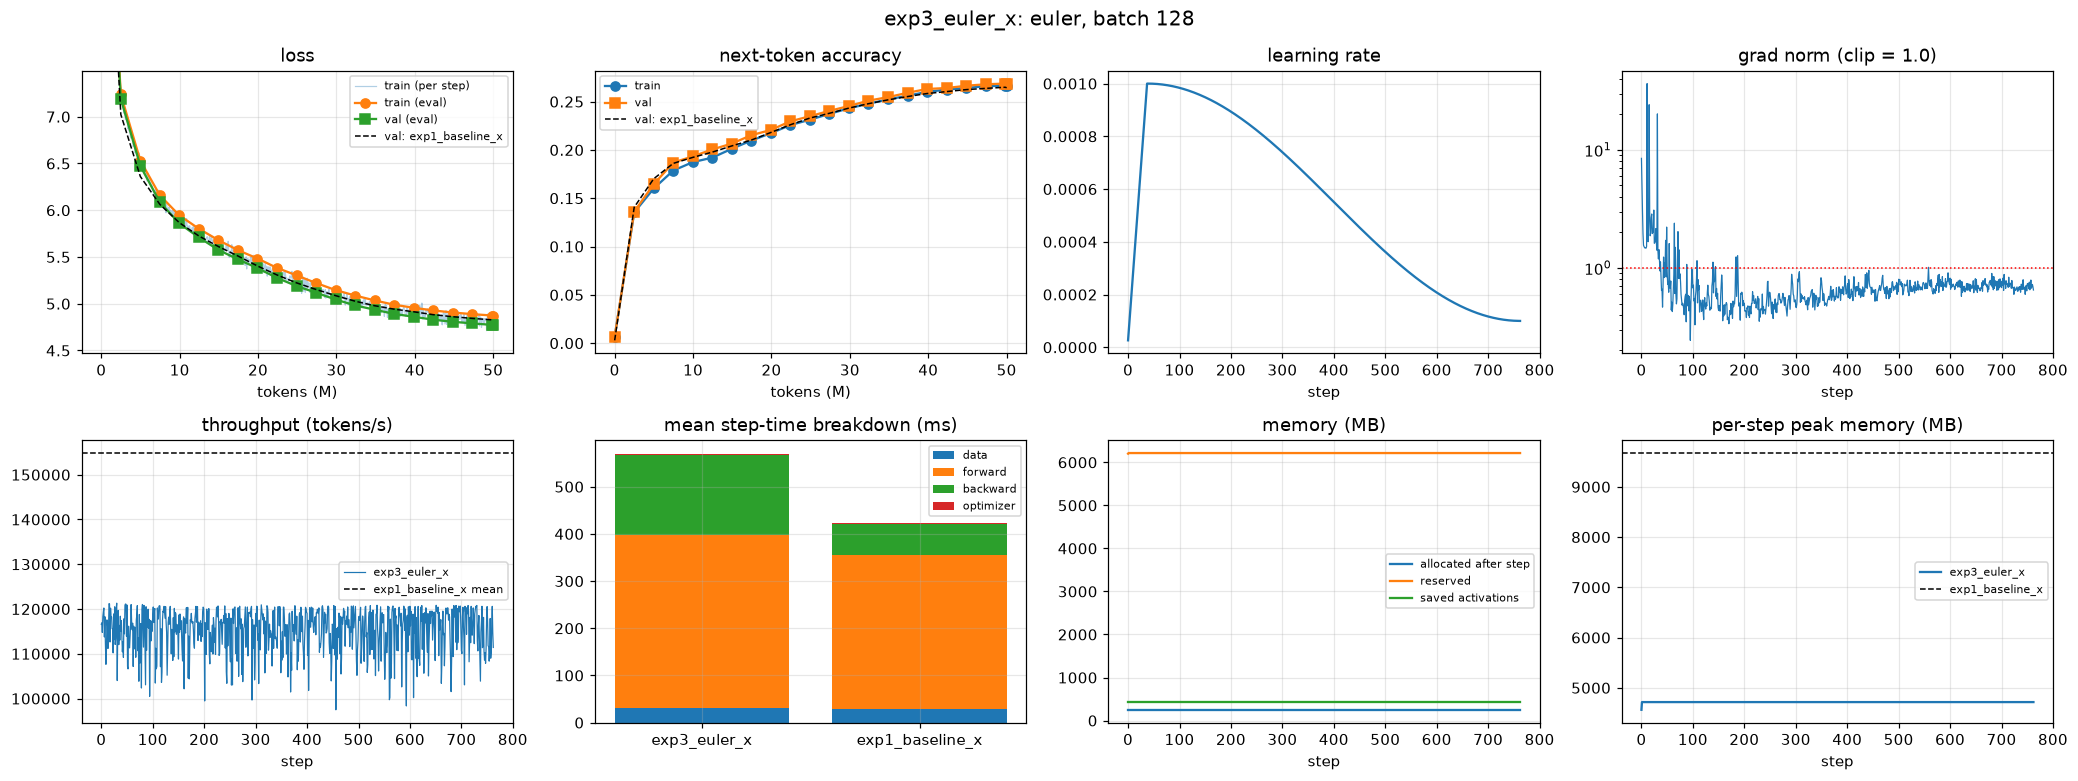

### Findings: `exp3_euler_x`

- **Quality:** final val loss **4.7745** (perplexity 118.4), val accuracy **27.22%**; train loss 4.8169, generalization gap -0.0424.
- **Convergence:** val loss moved only 0.0025 over the last 0.20M tokens and had flattened.
- **Speed:** 115,041 tokens/s (p10-p90: 108,212 to 120,440); step 570.8 ms = data 30.7 + forward 367.1 + backward 169.8 + optimizer 2.5 ms; wall clock 7.7 min. (Forward includes the fused lm_head gradient, see Section 3.)
- **Compute:** 15.4 model TFLOP/s (17.6 hardware TFLOP/s incl. recompute); MFU **9.9%**, HFU 11.3%; 6.69 PFLOP total.
- **Memory:** per-step peak **4,716 MB** (9.7% of the GPU); static 250 MB (params 78 + AdamW 154); activations saved for backward **434 MB** (of which 49 MB is the batch-independent fused-loss weight-gradient buffer) = **3.00 MB per sequence**.
- **Optimization:** 763 steps, peak LR 1.00e-03, mean grad norm 0.819 (max 36.47), clipped on 7.3% of steps.
- **Reversibility (trained weights, bf16):** max reconstruction drift 0.00e+00 (at the input: 0.00e+00); gradient vs plain autograd: cosine 1.000000, relative error 4.49e-04.

**Compared to `exp1_baseline_x`:** val loss -0.0534 (-1.11%), val accuracy +0.47 pts, throughput **-25.7%**, wall clock +31.0%, per-step peak memory **-51.2%**, activation memory per sequence **13.9x smaller**

In [18]:
LBL_EUL = "exp3_euler_x"
run_or_load("euler", BATCH_X, LBL_EUL)
report(LBL_EUL, LBL_BASE)

### Observed: experiment 3 (reversible Euler)

* **Quality, better than expected:** val loss **4.774, 0.053 below the baseline** and the best of all six runs (perplexity 118.4 vs 124.9, accuracy 27.22% vs 26.75%). The expectation was "slightly worse". The curve explains the change: Euler is **behind early** (+0.17 at 2.5M tokens, +0.11 at 5M), **crosses the baseline at ~10M tokens**, and then keeps widening its lead to −0.053. It reaches the baseline's final loss after **42.5M tokens, 15% fewer**.
* **A plausible reason:** the two-stream update carries **two** 256-wide residual states (q and p) through the depth at no parameter cost. Attention reads one stream and the MLP the other, a wider residual "memory", similar in spirit to multi-stream residual designs. The slower start fits this: each stream receives only half of the sub-layer updates at first. This is a hypothesis; with one seed, a 0.053 gap is suggestive but not proven. (At the tiny local scale, Euler was 0.034 *worse* than the baseline, so the advantage appears with more training.)
* **Memory:** identical to midpoint: **4.61 GB peak (−51%)**, 3.0 MB per sequence, reconstruction error 0, gradient cosine 0.99999994.
* **Speed:** **115.0k tokens/s (−25.7%)**, the slowest of the three. Backward takes 170 ms because it reconstructs two sub-layer updates per layer, and exact quantization costs Euler +26% (vs +13% for midpoint), since it quantizes two updates per layer instead of one.
* **Stability:** somewhat noisier gradients (mean norm 0.82 vs 0.55, clipped on 7.3% of steps vs 5.5%), with the largest spikes during warmup. There were no divergences.

---
## Choosing the reversible variant

**Decision rule (fixed before looking at the results):**

1. Discard a variant that did not finish (OOM or divergence), or whose reversible gradient disagrees with autograd (cosine < 0.999). Its memory savings would come at the cost of wrong gradients.
2. **Primary criterion: final validation loss** on the full validation split.
3. If the two are within **1%** in val loss (a practical tie at this scale), prefer higher **throughput**, then lower **peak memory**, then smaller **reconstruction drift**.

In [19]:
def comparison_frame(labels):
    keys = [
        "variant",
        "batch_size",
        "total_steps",
        "final_val_loss",
        "final_val_perplexity",
        "final_val_accuracy",
        "final_train_loss",
        "mean_tokens_per_sec",
        "mean_step_time_ms",
        "mean_forward_ms",
        "mean_backward_ms",
        "mfu",
        "wall_clock_s",
        "peak_step_memory_mb",
        "activation_saved_mb",
        "activation_saved_mb_per_sample",
        "mean_grad_norm",
        "frac_steps_clipped",
    ]
    df = pd.DataFrame(
        {lbl: {k: RECORDS[lbl]["summary"].get(k) for k in keys} for lbl in labels}
    ).T
    for lbl in labels:
        r = RECORDS[lbl]["summary"].get("reversibility") or {}
        df.loc[lbl, "recon_drift_max"] = r.get("max_rel_error")
        df.loc[lbl, "grad_cosine_vs_autograd"] = r.get("grad_cosine")
    return df


cmp3 = comparison_frame([LBL_BASE, LBL_MID, LBL_EUL])
display(cmp3)


def eligible(lbl):
    s = RECORDS[lbl]["summary"]
    r = s.get("reversibility") or {}
    return s["status"] == "ok" and (r.get("grad_cosine") or 0) >= 0.999


cands = [l for l in [LBL_MID, LBL_EUL] if eligible(l)]
assert cands, "neither reversible variant is usable, see the diagnostics above"
if len(cands) == 1:
    winner_lbl, reason = (
        cands[0],
        "the only variant passing the correctness and finished-run checks",
    )
else:
    m, e = (RECORDS[l]["summary"] for l in cands)
    gap = abs(m["final_val_loss"] - e["final_val_loss"]) / max(
        m["final_val_loss"], e["final_val_loss"]
    )
    if gap >= 0.01:
        winner_lbl = min(cands, key=lambda l: RECORDS[l]["summary"]["final_val_loss"])
        reason = f"lower final val loss (gap {gap:.2%} >= 1%)"
    else:
        winner_lbl = sorted(
            cands,
            key=lambda l: (
                -RECORDS[l]["summary"]["mean_tokens_per_sec"],
                RECORDS[l]["summary"]["peak_step_memory_mb"],
            ),
        )[0]
        reason = f"val losses tied (gap {gap:.2%} < 1%), so the higher-throughput variant wins"
WINNER = RECORDS[winner_lbl]["summary"]["variant"]
display(Markdown(f"## Selected variant: **`{WINNER}`** ({reason})"))

,variant,batch_size,total_steps,final_val_loss,final_val_perplexity,final_val_accuracy,final_train_loss,mean_tokens_per_sec,mean_step_time_ms,mean_forward_ms,mean_backward_ms,mfu,wall_clock_s,peak_step_memory_mb,activation_saved_mb,activation_saved_mb_per_sample,mean_grad_norm,frac_steps_clipped,recon_drift_max,grad_cosine_vs_autograd
exp1_baseline_x,baseline,128,763,4.827874,124.945023,0.26749,4.871543,154833.545784,424.591981,325.352285,66.607524,0.133847,354.562606,9672.257324,5402.083008,41.820343,0.55433,0.055046,None,None
exp2_midpoint_x,midpoint,128,763,4.841974,126.719207,0.264618,4.885491,126371.402621,519.596446,349.569282,138.625185,0.109243,423.952822,4716.336426,433.583008,3.003937,0.657599,0.057667,0.0,1.0
exp3_euler_x,euler,128,763,4.774484,118.449165,0.272222,4.816914,115041.441162,570.78,367.129957,169.802162,0.099448,464.35171,4716.336426,433.583008,3.003937,0.81949,0.073394,0.0,1.0


## Selected variant: **`euler`** (lower final val loss (gap 1.39% >= 1%))

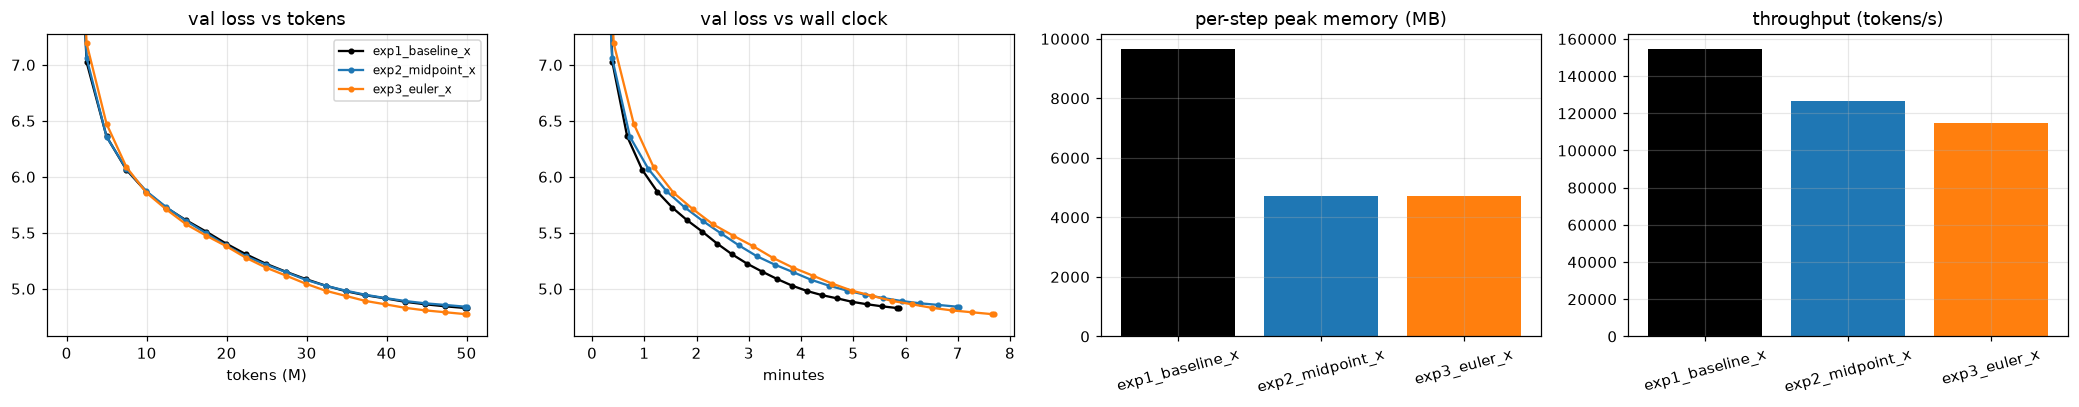


**Architecture comparison at the same batch size (128):**

| | baseline | midpoint | Euler |
|---|---|---|---|
| final val loss | 4.8279 | 4.8420 (+0.0141) | 4.7745 (-0.0534) |
| val accuracy | 26.75% | 26.46% | 27.22% |
| tokens/s | 154,834 | 126,371 (-18.4%) | 115,041 (-25.7%) |
| backward ms | 66.6 | 138.6 | 169.8 |
| per-step peak MB | 9,672 | 4,716 (-51.2%) | 4,716 (-51.2%) |
| saved activations MB/seq | 41.82 | 3.00 | 3.00 |
| reconstruction drift | - | 0.00e+00 | 0.00e+00 |

The per-step peak falls less than saved activations do because the peak also contains
the transient (chunk x vocab) fused-loss buffers and one layer's worth of recomputation
during backward. Those are constant or O(1) in depth, but they do not disappear.


In [20]:
fig, ax = plt.subplots(1, 4, figsize=(19, 3.8))
colors = {LBL_BASE: "k", LBL_MID: "tab:blue", LBL_EUL: "tab:orange"}
for lbl, c in colors.items():
    ev = RECORDS[lbl]["evals"]
    ax[0].plot(
        np.array(ev["tokens"]) / 1e6, ev["val_loss"], "o-", color=c, label=lbl, ms=3
    )
    ax[1].plot(
        np.array(ev["wall_clock_s"]) / 60,
        ev["val_loss"],
        "o-",
        color=c,
        label=lbl,
        ms=3,
    )
ax[0].set(
    title="val loss vs tokens",
    xlabel="tokens (M)",
    ylim=(min(cmp3.final_val_loss) - 0.2, min(cmp3.final_val_loss) + 2.5),
)
ax[1].set(title="val loss vs wall clock", xlabel="minutes", ylim=ax[0].get_ylim())
ax[0].legend(fontsize=8)
ax[2].bar(cmp3.index, cmp3.peak_step_memory_mb, color=list(colors.values()))
ax[2].set(title="per-step peak memory (MB)")
ax[2].tick_params(axis="x", rotation=15)
ax[3].bar(cmp3.index, cmp3.mean_tokens_per_sec, color=list(colors.values()))
ax[3].set(title="throughput (tokens/s)")
ax[3].tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.show()

b, m, e = (RECORDS[l]["summary"] for l in [LBL_BASE, LBL_MID, LBL_EUL])
display(
    Markdown(f"""
**Architecture comparison at the same batch size ({BATCH_X}):**

| | baseline | midpoint | Euler |
|---|---|---|---|
| final val loss | {b["final_val_loss"]:.4f} | {m["final_val_loss"]:.4f} ({m["final_val_loss"] - b["final_val_loss"]:+.4f}) | {e["final_val_loss"]:.4f} ({e["final_val_loss"] - b["final_val_loss"]:+.4f}) |
| val accuracy | {b["final_val_accuracy"] * 100:.2f}% | {m["final_val_accuracy"] * 100:.2f}% | {e["final_val_accuracy"] * 100:.2f}% |
| tokens/s | {b["mean_tokens_per_sec"]:,.0f} | {m["mean_tokens_per_sec"]:,.0f} ({_pct(m["mean_tokens_per_sec"], b["mean_tokens_per_sec"]):+.1f}%) | {e["mean_tokens_per_sec"]:,.0f} ({_pct(e["mean_tokens_per_sec"], b["mean_tokens_per_sec"]):+.1f}%) |
| backward ms | {b["mean_backward_ms"] or 0:.1f} | {m["mean_backward_ms"] or 0:.1f} | {e["mean_backward_ms"] or 0:.1f} |
| per-step peak MB | {b["peak_step_memory_mb"]:,.0f} | {m["peak_step_memory_mb"]:,.0f} ({_pct(m["peak_step_memory_mb"], b["peak_step_memory_mb"]):+.1f}%) | {e["peak_step_memory_mb"]:,.0f} ({_pct(e["peak_step_memory_mb"], b["peak_step_memory_mb"]):+.1f}%) |
| saved activations MB/seq | {b["activation_saved_mb_per_sample"]:.2f} | {m["activation_saved_mb_per_sample"]:.2f} | {e["activation_saved_mb_per_sample"]:.2f} |
| reconstruction drift | - | {(m.get("reversibility") or {}).get("max_rel_error", float("nan")):.2e} | {(e.get("reversibility") or {}).get("max_rel_error", float("nan")):.2e} |

The per-step peak falls less than saved activations do because the peak also contains
the transient (chunk x vocab) fused-loss buffers and one layer's worth of recomputation
during backward. Those are constant or O(1) in depth, but they do not disappear.
""")
)

### Why Euler, and what the choice costs

The pre-registered rule picks **Euler**: its val loss is 1.39% lower than midpoint's, above the 1% tie threshold. Both variants have identical memory (4.61 GB peak), both passed the gradient-correctness check, and both finished. What the rule trades away:

| criterion | midpoint | Euler | better |
|---|---:|---:|---|
| final val loss | 4.842 | **4.774** | Euler (−0.068) |
| throughput | **126.4k tok/s** | 115.0k tok/s | midpoint (+10%) |
| peak memory | 4.61 GB | 4.61 GB | tie |
| wall clock for 50M tokens | **7.1 min** | 7.7 min | midpoint |
| val loss at equal time (5.9 min) | 4.895 | **4.882** | Euler, narrowly |
| reconstruction error | 0 | 0 | tie |

Euler wins on loss per token, and even per unit of time it stays slightly ahead of midpoint. **Neither reversible model beats the baseline per unit of wall-clock time** on this GPU: at 5.9 min the baseline has finished at 4.828. Reversibility here buys memory, not speed. The next experiments ask whether that memory can be turned into anything useful through larger batches.

---
## Experiments 4-6: scaling the selected reversible variant to `2x`, `4x`, `8x`

The same 50M tokens each time, so each doubling of the batch halves the optimizer steps. The LR is sqrt-scaled (Section 6). Things to look for:

* **Memory** should grow roughly linearly with batch but with a ~20x smaller slope than the baseline. `8x` should fit where the baseline cannot (Section 5 probe).
* **Throughput** should rise as larger matmuls use the GPU better, then saturate.
* **Loss** at a fixed token budget typically *worsens* past the critical batch size, since fewer, larger steps are less token-efficient. The reversible model gives the *option* of large batches; whether they help is a separate question, and this is where it gets answered.

### Experiment 4: selected reversible variant, batch size `2x`

[train] exp4_euler_2x: variant=euler batch=256 steps=382 peak_lr=1.41e-03


exp4_euler_2x:   0%|          | 0/382 [00:00<?, ?it/s]

status=ok  log=/home/ravi.naik/learning/era/ERA/v5/session13/reversible_llm_experiments/notebooks/logs/exp4_euler_2x.log  aim_run=b0ebf7a834f04586aaa2722a


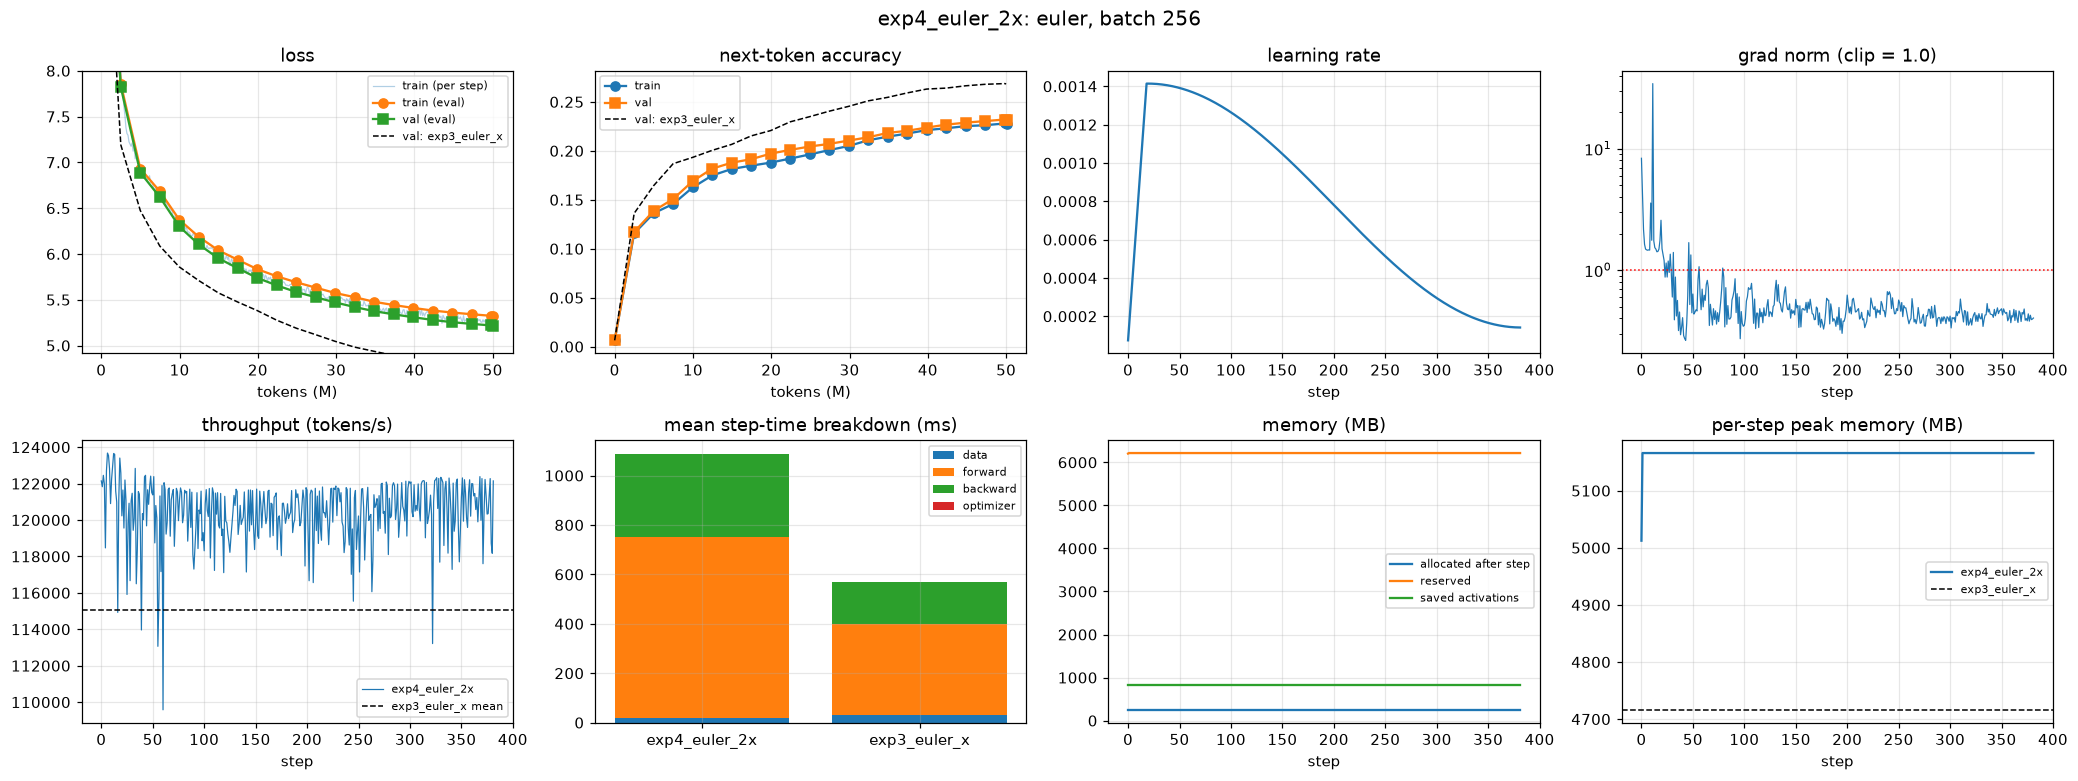

### Findings: `exp4_euler_2x`

- **Quality:** final val loss **5.2241** (perplexity 185.7), val accuracy **23.40%**; train loss 5.2663, generalization gap -0.0422.
- **Convergence:** val loss moved only 0.0027 over the last 0.26M tokens and had flattened.
- **Speed:** 120,364 tokens/s (p10-p90: 118,376 to 122,042); step 1089.2 ms = data 19.5 + forward 731.4 + backward 335.2 + optimizer 2.6 ms; wall clock 7.3 min. (Forward includes the fused lm_head gradient, see Section 3.)
- **Compute:** 16.1 model TFLOP/s (18.4 hardware TFLOP/s incl. recompute); MFU **10.4%**, HFU 11.9%; 6.7 PFLOP total.
- **Memory:** per-step peak **5,166 MB** (10.6% of the GPU); static 251 MB (params 78 + AdamW 155); activations saved for backward **818 MB** (of which 49 MB is the batch-independent fused-loss weight-gradient buffer) = **3.00 MB per sequence**.
- **Optimization:** 382 steps, peak LR 1.41e-03, mean grad norm 0.668 (max 34.37), clipped on 8.1% of steps.
- **Reversibility (trained weights, bf16):** max reconstruction drift 0.00e+00 (at the input: 0.00e+00); gradient vs plain autograd: cosine 0.999999, relative error 1.21e-03.

**Compared to `exp3_euler_x`:** val loss +0.4496 (+9.42%), val accuracy -3.83 pts, throughput **+4.6%**, wall clock -5.3%, per-step peak memory **+9.5%**, activation memory per sequence **1.0x smaller**

In [21]:
LBL_2X = f"exp4_{WINNER}_2x"
run_or_load(WINNER, 2 * BATCH_X, LBL_2X, LR_SCALING_FOR_SCALE_UP)
report(LBL_2X, winner_lbl)

**Observed (batch 256, 382 steps, peak LR 1.41e-3):** val loss **5.224 (+0.45 vs batch 128)**, 120.4k tokens/s (+4.6%), peak 5.04 GB (+0.44 GB for 128 more sequences). Halving the steps cost far more loss than the small throughput gain returned; wall clock fell only from 7.7 to 7.3 min.

### Experiment 5: selected reversible variant, batch size `4x`

[train] exp5_euler_4x: variant=euler batch=512 steps=191 peak_lr=2.00e-03


exp5_euler_4x:   0%|          | 0/191 [00:00<?, ?it/s]

status=ok  log=/home/ravi.naik/learning/era/ERA/v5/session13/reversible_llm_experiments/notebooks/logs/exp5_euler_4x.log  aim_run=c1c878645cb348a4ab9a91b9


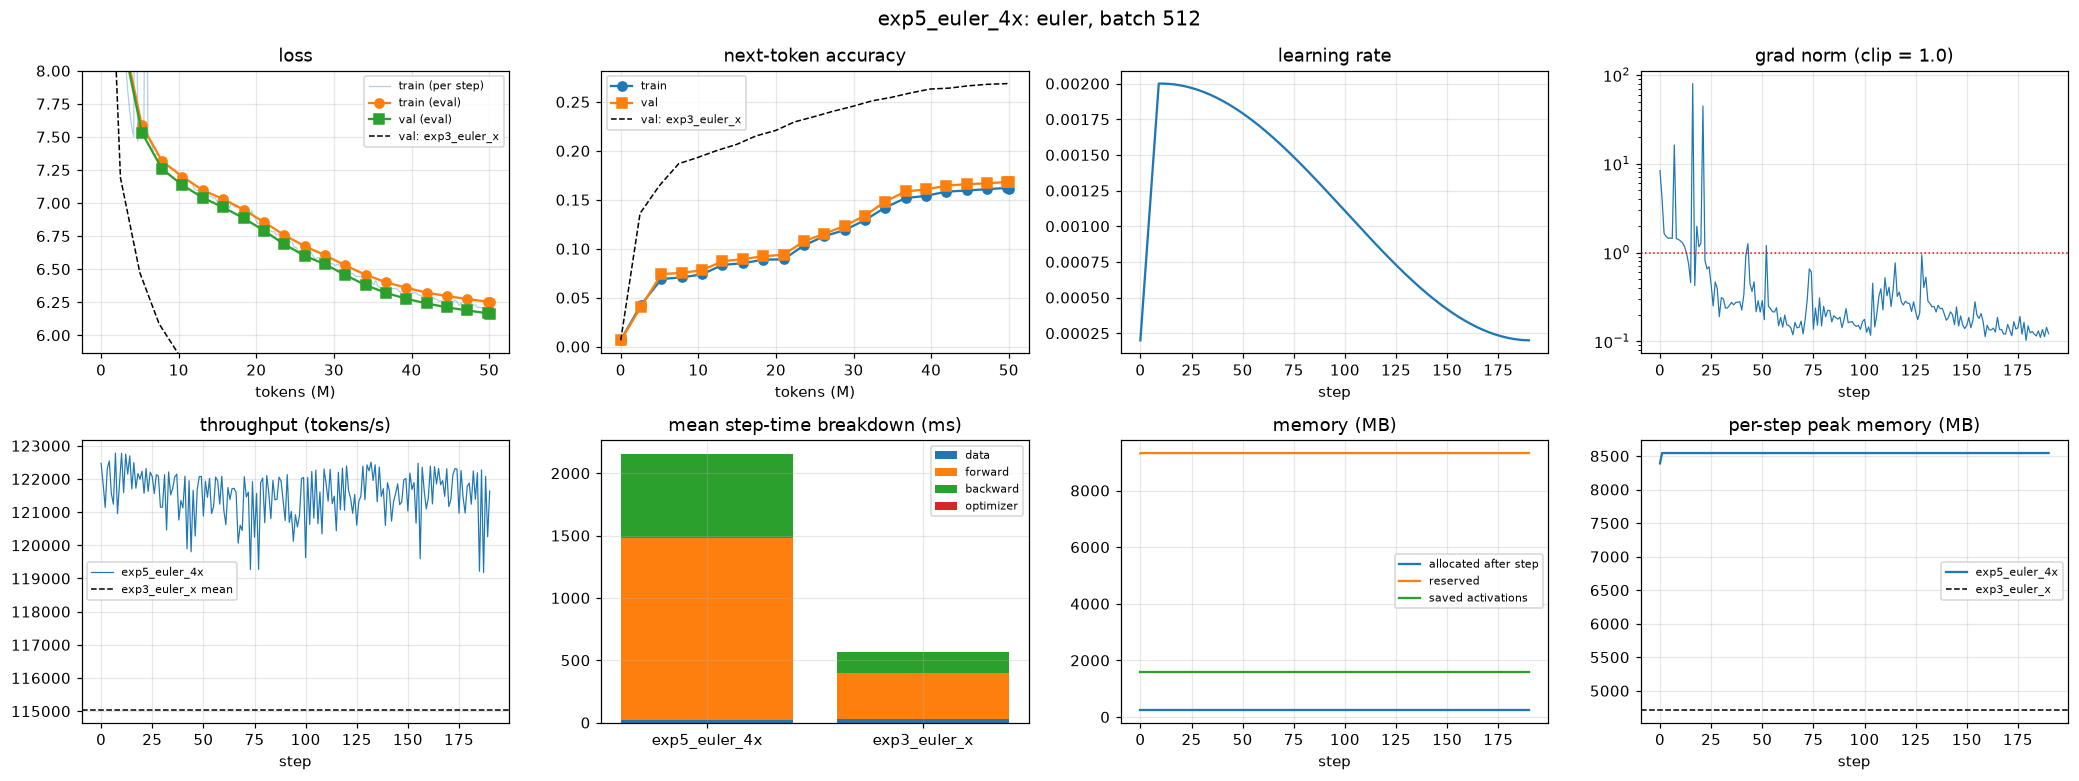

### Findings: `exp5_euler_4x`

- **Quality:** final val loss **6.1749** (perplexity 480.5), val accuracy **16.80%**; train loss 6.2019, generalization gap -0.0270.
- **Convergence:** val loss moved only 0.0016 over the last 0.26M tokens and had flattened.
- **Speed:** 121,520 tokens/s (p10-p90: 120,600 to 122,307); step 2157.3 ms = data 21.7 + forward 1460.0 + backward 672.4 + optimizer 2.5 ms; wall clock 7.2 min. (Forward includes the fused lm_head gradient, see Section 3.)
- **Compute:** 16.3 model TFLOP/s (18.6 hardware TFLOP/s incl. recompute); MFU **10.5%**, HFU 12.0%; 6.7 PFLOP total.
- **Memory:** per-step peak **8,544 MB** (17.6% of the GPU); static 253 MB (params 78 + AdamW 157); activations saved for backward **1,587 MB** (of which 49 MB is the batch-independent fused-loss weight-gradient buffer) = **3.00 MB per sequence**.
- **Optimization:** 191 steps, peak LR 2.00e-03, mean grad norm 1.135 (max 79.90), clipped on 10.5% of steps.
- **Reversibility (trained weights, bf16):** max reconstruction drift 0.00e+00 (at the input: 0.00e+00); gradient vs plain autograd: cosine 1.000000, relative error 5.16e-04.

**Compared to `exp3_euler_x`:** val loss +1.4004 (+29.33%), val accuracy -10.42 pts, throughput **+5.6%**, wall clock -6.6%, per-step peak memory **+81.2%**, activation memory per sequence **1.0x smaller**

In [22]:
LBL_4X = f"exp5_{WINNER}_4x"
run_or_load(WINNER, 4 * BATCH_X, LBL_4X, LR_SCALING_FOR_SCALE_UP)
report(LBL_4X, winner_lbl)

**Observed (batch 512, 191 steps, peak LR 2.0e-3):** val loss **6.175**. The run never reached val loss 6.0, which batch 128 passed after 10M tokens. Throughput was 121.5k tokens/s (+5.6%) and peak memory 8.34 GB. Here the baseline would already need 25.3 GB (Section 5).

### Experiment 6: selected reversible variant, batch size `8x`

[train] exp6_euler_8x: variant=euler batch=1024 steps=96 peak_lr=2.83e-03


exp6_euler_8x:   0%|          | 0/96 [00:00<?, ?it/s]

status=ok  log=/home/ravi.naik/learning/era/ERA/v5/session13/reversible_llm_experiments/notebooks/logs/exp6_euler_8x.log  aim_run=530e217b8ef94220b1d46041


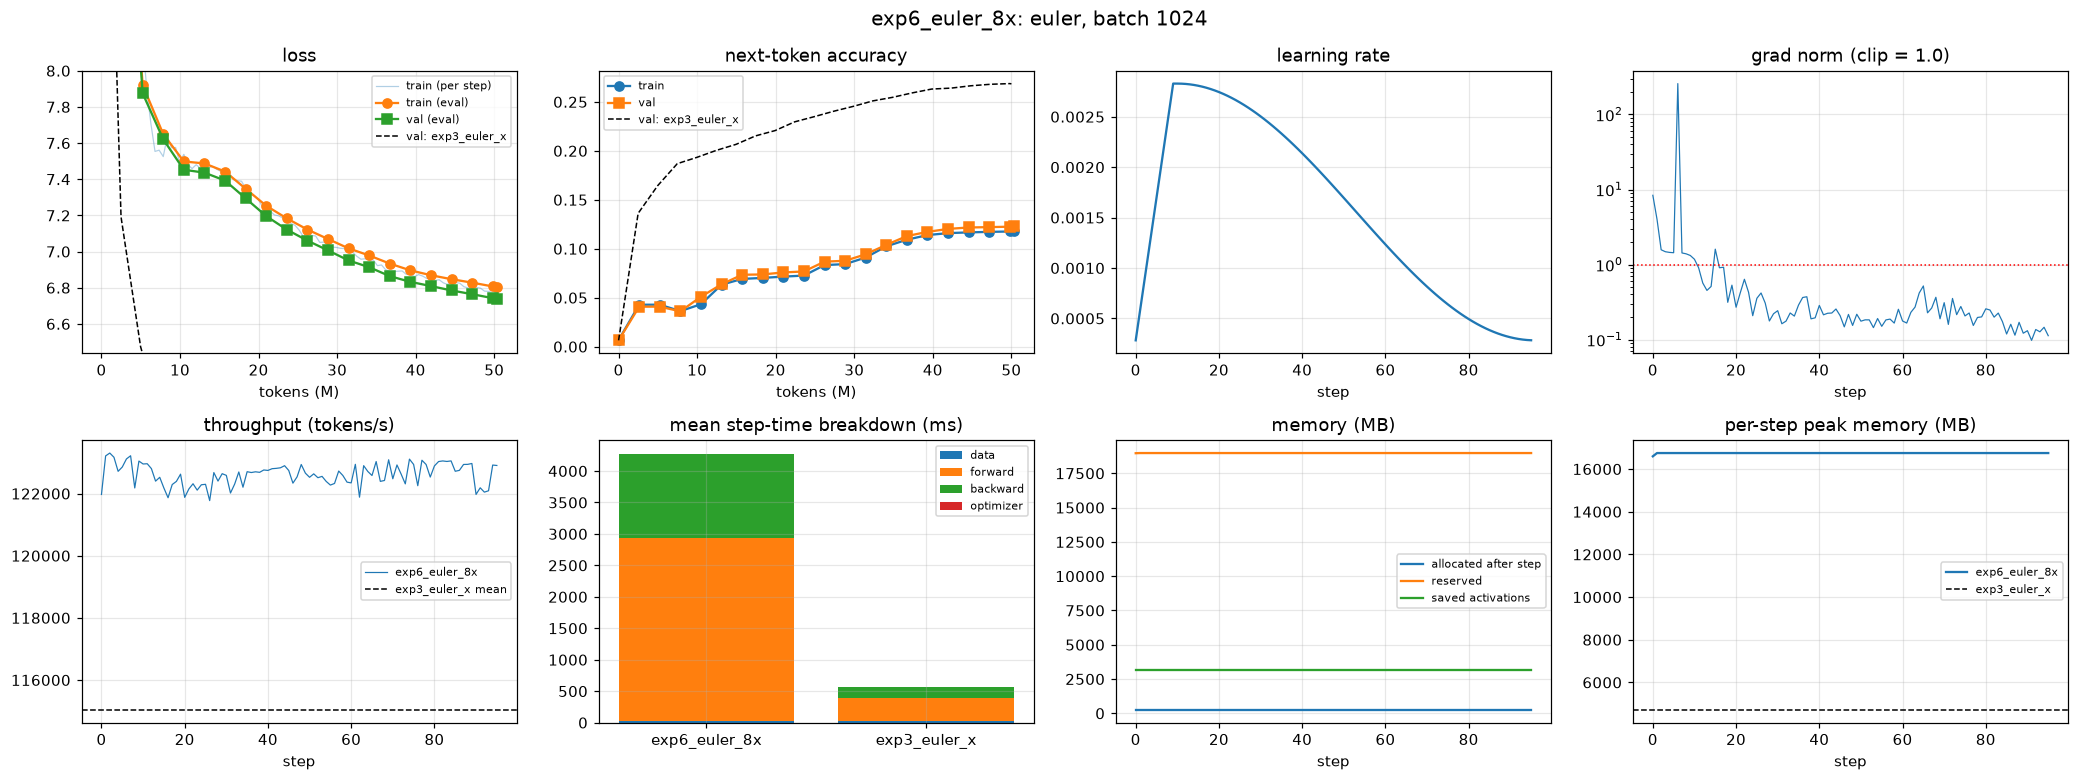

### Findings: `exp6_euler_8x`

- **Quality:** final val loss **6.7462** (perplexity 850.8), val accuracy **12.22%**; train loss 6.7623, generalization gap -0.0161.
- **Convergence:** val loss moved only 0.0043 over the last 0.52M tokens and had flattened.
- **Speed:** 122,599 tokens/s (p10-p90: 122,152 to 123,032); step 4276.5 ms = data 26.9 + forward 2915.4 + backward 1330.9 + optimizer 2.5 ms; wall clock 7.2 min. (Forward includes the fused lm_head gradient, see Section 3.)
- **Compute:** 16.4 model TFLOP/s (18.7 hardware TFLOP/s incl. recompute); MFU **10.6%**, HFU 12.1%; 6.74 PFLOP total.
- **Memory:** per-step peak **16,750 MB** (34.4% of the GPU); static 257 MB (params 78 + AdamW 161); activations saved for backward **3,125 MB** (of which 49 MB is the batch-independent fused-loss weight-gradient buffer) = **3.00 MB per sequence**.
- **Optimization:** 96 steps, peak LR 2.83e-03, mean grad norm 3.181 (max 257.49), clipped on 12.5% of steps.
- **Reversibility (trained weights, bf16):** max reconstruction drift 0.00e+00 (at the input: 0.00e+00); gradient vs plain autograd: cosine 1.000000, relative error 2.37e-04.

**Compared to `exp3_euler_x`:** val loss +1.9718 (+41.30%), val accuracy -15.00 pts, throughput **+6.6%**, wall clock -7.2%, per-step peak memory **+255.2%**, activation memory per sequence **1.0x smaller**

In [23]:
LBL_8X = f"exp6_{WINNER}_8x"
run_or_load(WINNER, 8 * BATCH_X, LBL_8X, LR_SCALING_FOR_SCALE_UP)
report(LBL_8X, winner_lbl)

**Observed (batch 1024, 96 steps, peak LR 2.83e-3):** val loss **6.746**, 122.6k tokens/s (+6.6%), peak **16.36 GB (34% of the GPU)**. The baseline cannot run this configuration at all. Optimization was visibly strained: mean gradient norm 3.18 (max 257), 12.5% of steps clipped, and with only 10 warmup steps the LR jumps to 2.83e-3 within the first 5M tokens.

,variant,batch_size,total_steps,final_val_loss,final_val_perplexity,final_val_accuracy,final_train_loss,mean_tokens_per_sec,mean_step_time_ms,mean_forward_ms,mean_backward_ms,mfu,wall_clock_s,peak_step_memory_mb,activation_saved_mb,activation_saved_mb_per_sample,mean_grad_norm,frac_steps_clipped,recon_drift_max,grad_cosine_vs_autograd,peak_lr
exp3_euler_x,euler,128,763,4.774484,118.449165,0.272222,4.816914,115041.441162,570.78,367.129957,169.802162,0.099448,464.35171,4716.336426,433.583008,3.003937,0.81949,0.073394,0.0,1.000000,0.001000
exp4_euler_2x,euler,256,382,5.224084,185.690933,0.233962,5.266308,120363.545625,1089.178847,731.389707,335.223553,0.104049,439.930751,5165.836426,818.083008,3.003922,0.668263,0.081152,0.0,0.999999,0.001414
exp5_euler_4x,euler,512,191,6.174924,480.546657,0.168025,6.201899,121519.716593,2157.293598,1460.034671,672.40198,0.105049,433.690015,8544.078613,1587.083008,3.003914,1.13485,0.104712,0.0,1.000000,0.002000
exp6_euler_8x,euler,1024,96,6.746235,850.849433,0.122237,6.762287,122599.486519,4276.461834,2915.445026,1330.935256,0.105982,430.962717,16750.078613,3125.083008,3.00391,3.181237,0.125,0.0,1.000000,0.002828


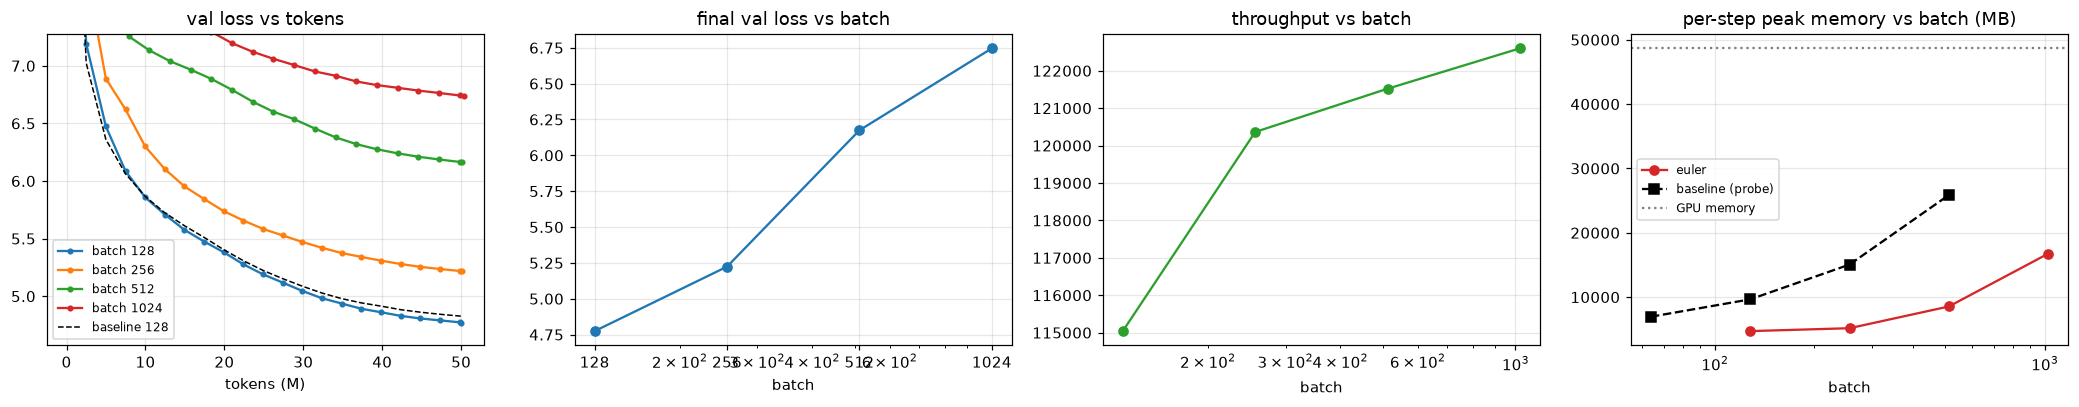

| batch | steps | val loss | val acc | tokens/s | peak MB | wall clock (min) |
|---|---|---|---|---|---|---|
| 128 | 763 | 4.7745 | 27.22% | 115,041 | 4,716 | 7.7 |
| 256 | 382 | 5.2241 | 23.40% | 120,364 | 5,166 | 7.3 |
| 512 | 191 | 6.1749 | 16.80% | 121,520 | 8,544 | 7.2 |
| 1024 | 96 | 6.7462 | 12.22% | 122,599 | 16,750 | 7.2 |

From `x` to `8x`: throughput **+6.6%**, peak memory **+255.2%** (16.4 GB), val loss **+1.9718** with 7x fewer optimizer steps. Relative to the **baseline at x**, `8x` uses +73.2% peak memory for 8x the batch.

In [24]:
scale_lbls = [winner_lbl, LBL_2X, LBL_4X, LBL_8X]
scale = comparison_frame(scale_lbls)
scale["peak_lr"] = [RECORDS[l]["summary"]["peak_lr"] for l in scale_lbls]
display(scale)

ok = scale[[RECORDS[l]["summary"]["status"] == "ok" for l in scale_lbls]]
fig, ax = plt.subplots(1, 4, figsize=(19, 3.8))
for lbl in ok.index:
    ev = RECORDS[lbl]["evals"]
    ax[0].plot(
        np.array(ev["tokens"]) / 1e6,
        ev["val_loss"],
        "o-",
        ms=3,
        label=f"batch {RECORDS[lbl]['summary']['batch_size']}",
    )
ev = RECORDS[LBL_BASE]["evals"]
ax[0].plot(
    np.array(ev["tokens"]) / 1e6,
    ev["val_loss"],
    "k--",
    lw=1,
    label=f"baseline {BATCH_X}",
)
ax[0].set(
    title="val loss vs tokens",
    xlabel="tokens (M)",
    ylim=(ok.final_val_loss.min() - 0.2, ok.final_val_loss.min() + 2.5),
)
ax[0].legend(fontsize=8)
ax[1].plot(ok.batch_size, ok.final_val_loss, "o-")
ax[1].set(
    title="final val loss vs batch",
    xlabel="batch",
    xscale="log",
    xticks=list(ok.batch_size),
    xticklabels=list(ok.batch_size),
)
ax[2].plot(ok.batch_size, ok.mean_tokens_per_sec, "o-", color="tab:green")
ax[2].set(title="throughput vs batch", xlabel="batch", xscale="log")
ax[3].plot(
    ok.batch_size, ok.peak_step_memory_mb, "o-", color="tab:red", label=f"{WINNER}"
)
if len(probe_df):
    bp = probe_df[(probe_df.variant == "baseline") & probe_df.fits]
    ax[3].plot(
        bp.batch_size, bp.peak_memory_mb, "s--", color="k", label="baseline (probe)"
    )
if GPU_TOTAL_MB:
    ax[3].axhline(GPU_TOTAL_MB, color="gray", ls=":", label="GPU memory")
ax[3].set(title="per-step peak memory vs batch (MB)", xlabel="batch", xscale="log")
ax[3].legend(fontsize=8)
fig.tight_layout()
plt.show()

rows = []
for lbl in scale_lbls:
    s = RECORDS[lbl]["summary"]
    if s["status"] != "ok":
        rows.append(
            f"| {s['batch_size']} | {s['total_steps']} | **{s['status']}** | | | | |"
        )
        continue
    rows.append(
        f"| {s['batch_size']} | {s['total_steps']} | {s['final_val_loss']:.4f} | {s['final_val_accuracy'] * 100:.2f}% | "
        f"{s['mean_tokens_per_sec']:,.0f} | {s['peak_step_memory_mb']:,.0f} | {s['wall_clock_s'] / 60:.1f} |"
    )
x0, x8 = RECORDS[winner_lbl]["summary"], RECORDS[LBL_8X]["summary"]
text = [
    "| batch | steps | val loss | val acc | tokens/s | peak MB | wall clock (min) |",
    "|---|---|---|---|---|---|---|",
    *rows,
    "",
]
if x8["status"] == "ok":
    text.append(
        f"From `x` to `8x`: throughput **{_pct(x8['mean_tokens_per_sec'], x0['mean_tokens_per_sec']):+.1f}%**, "
        f"peak memory **{_pct(x8['peak_step_memory_mb'], x0['peak_step_memory_mb']):+.1f}%** "
        f"({x8['peak_step_memory_mb'] / 1024:.1f} GB), val loss **{x8['final_val_loss'] - x0['final_val_loss']:+.4f}** "
        f"with {x0['total_steps'] // max(1, x8['total_steps'])}x fewer optimizer steps. "
        f"Relative to the **baseline at x**, `8x` uses {_pct(x8['peak_step_memory_mb'], b['peak_step_memory_mb']):+.1f}% "
        f"peak memory for 8x the batch."
    )
display(Markdown("\n".join(text)))

### What the scaling experiments show

* **Memory scaled as designed.** Peak memory grows ~16 MB per extra sequence, against ~42 MB for the baseline. 8x the batch needs 16.4 GB, **less than twice the baseline's 9.45 GB at 1x**.
* **Speed barely moved.** Throughput rose only 6.6% from batch 128 to 1024, because the GPU was already saturated at 128 (see the flat probe throughput in Section 5). Wall clock per 50M tokens fell from 7.7 to 7.2 min.
* **Loss got much worse,** from 4.77 to 5.22, 6.17 and 6.75. At a fixed token budget, a larger batch means fewer optimizer steps, and each doubling here cost far more than it saved. This is the classic **critical batch size** effect: early in training the gradient noise is small compared with the signal, so larger batches waste tokens. For a 20M model at this stage, 128 x 512 = 65k tokens per step is already at or above the efficient batch. sqrt LR scaling did not compensate: the larger learning rates added gradient spikes (max norm 257 at 8x) rather than progress.
* **Takeaway:** the reversible model gave the *option* of an 8x batch at half the baseline's memory per sequence. On this model and budget that option was not worth taking. Its value lies elsewhere: deeper models, longer contexts, or smaller GPUs, where the baseline would not fit at all.

---
## Where is the maximum? Largest batch that fits: baseline vs selected reversible variant

The equivalent of the paper's Table 3 on *this* GPU: the largest batch (to the nearest 32) for which a real training step (forward, backward, AdamW) fits. The search doubles until OOM, then bisects. This establishes that `8x` really is within the reversible model's range and shows how much headroom remains beyond it.

In [25]:
max_batch = {}
max_rows = []
if IS_CUDA:
    for variant in ["baseline", WINNER]:
        cfg = GPTConfig(
            vocab_size=data.vocab_size,
            block_size=BLOCK_SIZE,
            variant=variant,
            loss_chunk_size=LOSS_CHUNK,
            **MODEL,
        )
        max_batch[variant], rows = find_max_batch(
            cfg,
            DEVICE,
            start=BATCH_X,
            limit=MAX_BATCH_SEARCH_LIMIT,
            granularity=MAX_BATCH_GRANULARITY,
        )
        max_rows += rows
    max_df = pd.DataFrame(max_rows)
    display(
        max_df[
            [
                "variant",
                "batch_size",
                "fits",
                "peak_memory_mb",
                "activation_saved_mb_per_sample",
                "tokens_per_sec",
            ]
        ]
    )
    ratio = max_batch[WINNER] / max(1, max_batch["baseline"])
    display(
        Markdown(
            f"**Max batch on {ENV.get('gpu_name')} ({(GPU_TOTAL_MB or 0) / 1024:.0f} GB):** baseline **{max_batch['baseline']}**, "
            f"{WINNER} **{max_batch[WINNER]}**, which is **{ratio:.1f}x larger**. "
            f"Experiment 6 used {8 * BATCH_X} = {8 * BATCH_X / max(1, max_batch[WINNER]) * 100:.0f}% of the reversible maximum, "
            f"and {8 * BATCH_X / max(1, max_batch['baseline']):.1f}x the baseline's maximum. "
            f"(For reference, the paper reports ~10x on A100 and H100 for GPT-2 sized models; our model's 50k-vocab head is "
            f"a larger share of total memory, which caps the ratio.)"
        )
    )

,variant,batch_size,fits,peak_memory_mb,activation_saved_mb_per_sample,tokens_per_sec
0,baseline,128,True,9653.474121,41.820347,166720.347717
1,baseline,256,True,15057.474121,41.767595,168542.153757
2,baseline,512,True,25864.553223,41.741220,168523.230958
3,baseline,1024,False,NaN,NaN,NaN
4,baseline,768,True,36674.162598,41.733567,169061.791118
5,baseline,896,True,42078.491699,41.731259,169030.976787
6,baseline,960,False,NaN,NaN,NaN
7,baseline,928,False,NaN,NaN,NaN
8,euler,128,True,4698.287598,3.003941,121917.335546
9,euler,256,True,5147.287598,3.003923,123317.246693


**Max batch on NVIDIA RTX A6000 (48 GB):** baseline **896**, euler **2528**, which is **2.8x larger**. Experiment 6 used 1024 = 41% of the reversible maximum, and 1.1x the baseline's maximum. (For reference, the paper reports ~10x on A100 and H100 for GPT-2 sized models; our model's 50k-vocab head is a larger share of total memory, which caps the ratio.)

**Observed.** On the RTX A6000 (48 GB) the maximum batch is **896 for the baseline and 2528 for Euler: 2.8x larger**. Experiment 6 (batch 1024) used 41% of Euler's maximum and is 1.14x the baseline's maximum.

Why 2.8x and not the paper's ~10x:

* **The peak slope, not the stored activations, sets the limit.** Stored activations are 14x smaller (3.0 vs 41.8 MB per sequence), but during backward the reversible model also holds one layer's reconstruction working set, the float64 streams, and their gradients. Its *peak* grows ~16 MB per sequence, against ~42 MB for the baseline, a ratio of 2.6x. That matches the measured 2.8x.
* **The model is shallow.** Reversible savings scale with depth, and at 9 layers the per-layer working set is a large share of the peak. The paper's largest gains come from GPT-2 variants and 96-layer models, where the baseline stores 10x more.
* **Most of the parameters are the head.** 64% of parameters sit in the tied 50,257-token embedding and head, whose loss buffers are identical in both architectures.

---
## Final comparison: all six experiments

,experiment,variant,batch_size,total_steps,final_val_loss,final_val_perplexity,final_val_accuracy,final_train_loss,mean_tokens_per_sec,mean_step_time_ms,mean_forward_ms,mean_backward_ms,mfu,wall_clock_s,peak_step_memory_mb,activation_saved_mb,activation_saved_mb_per_sample,mean_grad_norm,frac_steps_clipped,recon_drift_max,grad_cosine_vs_autograd,status
exp1_baseline_x,1,baseline,128,763,4.827874,124.945023,0.26749,4.871543,154833.545784,424.591981,325.352285,66.607524,0.133847,354.562606,9672.257324,5402.083008,41.820343,0.55433,0.055046,None,None,ok
exp2_midpoint_x,2,midpoint,128,763,4.841974,126.719207,0.264618,4.885491,126371.402621,519.596446,349.569282,138.625185,0.109243,423.952822,4716.336426,433.583008,3.003937,0.657599,0.057667,0.0,1.0,ok
exp3_euler_x,3,euler,128,763,4.774484,118.449165,0.272222,4.816914,115041.441162,570.78,367.129957,169.802162,0.099448,464.35171,4716.336426,433.583008,3.003937,0.81949,0.073394,0.0,1.0,ok
exp4_euler_2x,4,euler,256,382,5.224084,185.690933,0.233962,5.266308,120363.545625,1089.178847,731.389707,335.223553,0.104049,439.930751,5165.836426,818.083008,3.003922,0.668263,0.081152,0.0,0.999999,ok
exp5_euler_4x,5,euler,512,191,6.174924,480.546657,0.168025,6.201899,121519.716593,2157.293598,1460.034671,672.40198,0.105049,433.690015,8544.078613,1587.083008,3.003914,1.13485,0.104712,0.0,1.0,ok
exp6_euler_8x,6,euler,1024,96,6.746235,850.849433,0.122237,6.762287,122599.486519,4276.461834,2915.445026,1330.935256,0.105982,430.962717,16750.078613,3125.083008,3.00391,3.181237,0.125,0.0,1.0,ok


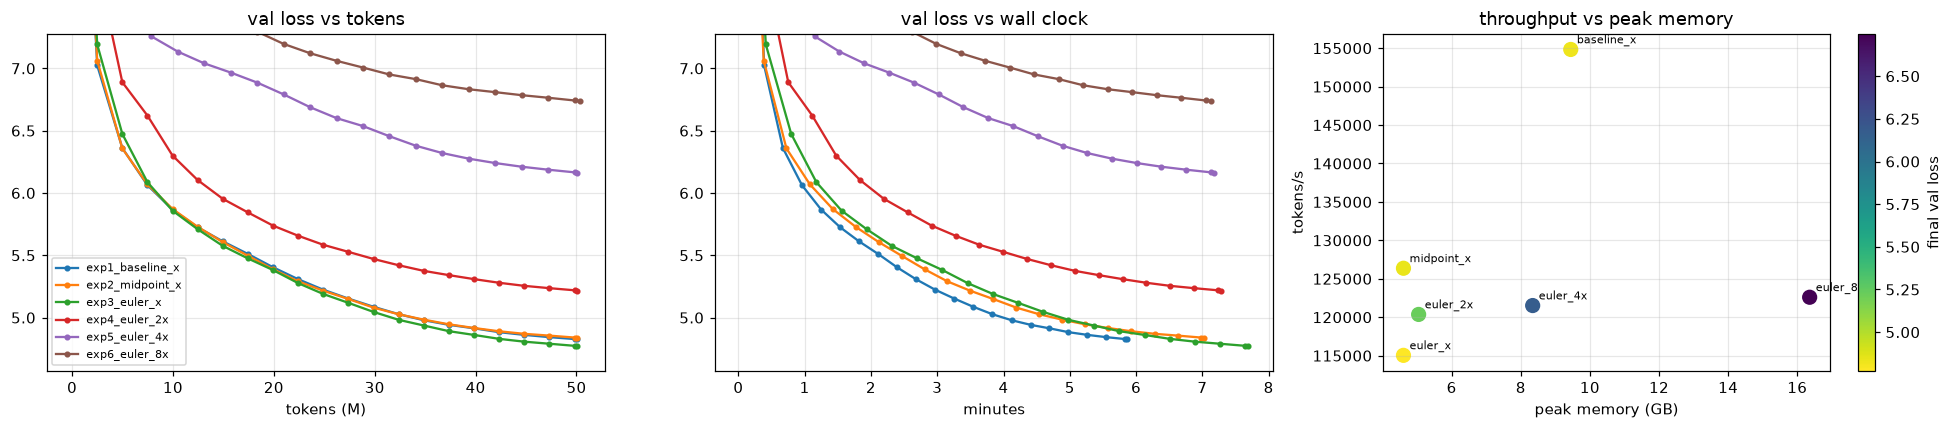

In [29]:
ALL = [LBL_BASE, LBL_MID, LBL_EUL, LBL_2X, LBL_4X, LBL_8X]
final_df = comparison_frame(ALL)
final_df.insert(0, "experiment", [1, 2, 3, 4, 5, 6])
final_df["status"] = [RECORDS[l]["summary"]["status"] for l in ALL]
display(final_df)
final_df.to_csv(RESULTS_DIR / "final_comparison.csv")

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
for lbl in ALL:
    if RECORDS[lbl]["summary"]["status"] != "ok":
        continue
    ev = RECORDS[lbl]["evals"]
    ax[0].plot(np.array(ev["tokens"]) / 1e6, ev["val_loss"], "o-", ms=3, label=lbl)
    ax[1].plot(np.array(ev["wall_clock_s"]) / 60, ev["val_loss"], "o-", ms=3, label=lbl)
ok_all = final_df[final_df.status == "ok"]
for a, t, xl in [
    (ax[0], "val loss vs tokens", "tokens (M)"),
    (ax[1], "val loss vs wall clock", "minutes"),
]:
    a.set(
        title=t,
        xlabel=xl,
        ylim=(ok_all.final_val_loss.min() - 0.2, ok_all.final_val_loss.min() + 2.5),
    )
ax[0].legend(fontsize=7)
sc = ax[2].scatter(
    ok_all.peak_step_memory_mb / 1024,
    ok_all.mean_tokens_per_sec,
    s=80,
    c=ok_all.final_val_loss.astype(float),
    cmap="viridis_r",
)
for lbl, row in ok_all.iterrows():
    ax[2].annotate(
        lbl.split("_", 1)[1],
        (row.peak_step_memory_mb / 1024, row.mean_tokens_per_sec),
        fontsize=7,
        xytext=(4, 4),
        textcoords="offset points",
    )
plt.colorbar(sc, ax=ax[2], label="final val loss")
ax[2].set(
    title="throughput vs peak memory", xlabel="peak memory (GB)", ylabel="tokens/s"
)
fig.tight_layout()
plt.show()

## Conclusions

The summary below is generated from the measured numbers above, so it stays in sync with whatever this notebook actually ran.

In [27]:
S = {l: RECORDS[l]["summary"] for l in ALL}
b, w = S[LBL_BASE], S[winner_lbl]
loser_lbl = LBL_EUL if winner_lbl == LBL_MID else LBL_MID
lo = S[loser_lbl]
ok_runs = [l for l in ALL if S[l]["status"] == "ok"]
best = min(ok_runs, key=lambda l: S[l]["final_val_loss"])
fastest = max(ok_runs, key=lambda l: S[l]["mean_tokens_per_sec"])
lines = [
    "### 1. Architecture (same batch, same data)",
    f"- **Memory:** reversible `{WINNER}` saved **{b['activation_saved_mb_per_sample'] / w['activation_saved_mb_per_sample']:.0f}x less** activation memory "
    f"per sequence than the baseline ({w['activation_saved_mb_per_sample']:.2f} vs {b['activation_saved_mb_per_sample']:.2f} MB), and per-step peak memory changed by "
    f"**{_pct(w['peak_step_memory_mb'], b['peak_step_memory_mb']):+.1f}%**.",
    f"- **Speed:** throughput changed by **{_pct(w['mean_tokens_per_sec'], b['mean_tokens_per_sec']):+.1f}%** "
    f"({w['mean_tokens_per_sec']:,.0f} vs {b['mean_tokens_per_sec']:,.0f} tokens/s). This is the cost of reconstructing activations in backward, "
    f"compared with the ~{(flops_rows['midpoint']['recompute overhead']) * 100:.0f}% extra FLOPs predicted analytically.",
    f"- **Quality:** val loss {w['final_val_loss']:.4f} vs baseline {b['final_val_loss']:.4f} (**{w['final_val_loss'] - b['final_val_loss']:+.4f}**); "
    f"the other reversible variant reached {lo['final_val_loss']:.4f}.",
    f"- **Selection:** `{WINNER}`, because {reason}.",
    "",
    "### 2. Batch-size scaling of the selected variant",
]
for l in [winner_lbl, LBL_2X, LBL_4X, LBL_8X]:
    s = S[l]
    if s["status"] == "ok":
        lines.append(
            f"- batch **{s['batch_size']}**: val loss {s['final_val_loss']:.4f}, {s['mean_tokens_per_sec']:,.0f} tokens/s, "
            f"peak {s['peak_step_memory_mb'] / 1024:.1f} GB, {s['wall_clock_s'] / 60:.1f} min"
        )
    else:
        lines.append(f"- batch **{s['batch_size']}**: **{s['status']}**")
if max_batch:
    lines.append(
        f"- Largest trainable batch on this GPU: baseline **{max_batch['baseline']}** vs {WINNER} **{max_batch[WINNER]}** "
        f"(**{max_batch[WINNER] / max(1, max_batch['baseline']):.1f}x**)."
    )
lines += [
    "",
    "### 3. Overall",
    f"- Lowest val loss: `{best}` ({S[best]['final_val_loss']:.4f}); highest throughput: `{fastest}` ({S[fastest]['mean_tokens_per_sec']:,.0f} tokens/s).",
]
display(Markdown("\n".join(lines)))

### 1. Architecture (same batch, same data)
- **Memory:** reversible `euler` saved **14x less** activation memory per sequence than the baseline (3.00 vs 41.82 MB), and per-step peak memory changed by **-51.2%**.
- **Speed:** throughput changed by **-25.7%** (115,041 vs 154,834 tokens/s). This is the cost of reconstructing activations in backward, compared with the ~14% extra FLOPs predicted analytically.
- **Quality:** val loss 4.7745 vs baseline 4.8279 (**-0.0534**); the other reversible variant reached 4.8420.
- **Selection:** `euler`, because lower final val loss (gap 1.39% >= 1%).

### 2. Batch-size scaling of the selected variant
- batch **128**: val loss 4.7745, 115,041 tokens/s, peak 4.6 GB, 7.7 min
- batch **256**: val loss 5.2241, 120,364 tokens/s, peak 5.0 GB, 7.3 min
- batch **512**: val loss 6.1749, 121,520 tokens/s, peak 8.3 GB, 7.2 min
- batch **1024**: val loss 6.7462, 122,599 tokens/s, peak 16.4 GB, 7.2 min
- Largest trainable batch on this GPU: baseline **896** vs euler **2528** (**2.8x**).

### 3. Overall
- Lowest val loss: `exp3_euler_x` (4.7745); highest throughput: `exp1_baseline_x` (154,834 tokens/s).

**Summary of the evidence**

```text
                      memory (peak, GB)   loss (val)   speed (k tok/s)   max batch (48 GB)
baseline   @128            9.45             4.828          154.8               896
midpoint   @128            4.61             4.842          126.4                 -
euler      @128            4.61             4.774          115.0              2528
euler      @1024          16.36             6.746          122.6                 -
```

**Recommendations**

* **To train a model that does not fit, use reversible Euler with exact streams.** It halves peak memory, keeps activation memory flat in depth, and here even matched or beat the baseline's loss per token.
* **For wall-clock speed, when memory is not the constraint, use the plain baseline.** On this GPU the reversible models are 18-26% slower, and the extra memory did not convert into a better batch size.
* **Do not raise the batch just because it fits.** At a fixed token budget the extra optimizer steps matter more. Spend the saved memory on depth, context length or model size instead.
* **Next experiments:** repeat with 2-3 seeds to confirm the Euler gain; try a deeper, narrower model (24-48 layers), where the depth savings dominate; use a GPU with fast fp64 or a cheaper exact scheme (e.g. int32 fixed-point streams); and give large-batch runs a longer warmup or a larger token budget.

**How to read these results**

* **Reversibility is a memory tool.** It trades ~14% extra compute (one extra backbone forward) for activation memory that is constant in depth. For a 9-layer, 20M-parameter model that already fits comfortably, that trade only pays off if the freed memory buys something, such as a larger batch (which can raise throughput by using the GPU better) or, at real scale, a deeper or longer-context model that otherwise would not fit at all. The paper's throughput *gains* come from exactly this: larger batches on memory-bound deep models (96 layers).
* **At a fixed token budget, bigger batches mean fewer optimizer steps.** If loss worsens from `x` to `8x`, the runs have passed the critical batch size for this model and budget. That is an optimization effect, not a flaw in the reversible model. The memory headroom lets you choose the batch, but it does not make large batches token-efficient.
* **Exact reversal matters.** With plain floating-point streams, reconstruction error grows as training sharpens the layers (Section 4.4: gradient cosine as low as 0.50), and the model is trained on subtly wrong gradients. Fixed-point streams remove the issue entirely: all four reversible training runs reconstructed with **zero** error, at the price of 2x the (small) stream memory and a 13-26% slowdown on a GPU with slow fp64. The paper does not discuss this; it is the implementation detail most worth keeping.

## Artifacts and reproducibility

In [28]:
webapp_js = ROOT.parent.parent / "webapp" / "data.js"
session_data = export_webapp_data(RESULTS_DIR / "runs.jsonl", webapp_js, winner=WINNER)
print("webapp data written to", webapp_js)
files = sorted(
    p.relative_to(ROOT)
    for d in [RESULTS_DIR, LOG_DIR]
    for p in d.glob("*")
    if p.is_file()
)
display(
    pd.DataFrame(
        {
            "file": [str(f) for f in files],
            "size_kb": [round((ROOT / f).stat().st_size / 1024, 1) for f in files],
        }
    )
)
# Aim writes every metric while training, but finished runs only show up in queries
# (and immediately in the UI) once the repo index is rebuilt. `aim up` also does this.
import subprocess, sys

aim_bin = Path(sys.executable).parent / "aim"
res = subprocess.run(
    [str(aim_bin), "storage", "--repo", AIM_REPO, "reindex", "--yes"],
    capture_output=True,
    text=True,
)
print("aim reindex:", "ok" if res.returncode == 0 else res.stderr[-500:])
print("Aim: run `uv run aim up` from", ROOT, "| experiment:", EXPERIMENT)
print("Aim run hashes:", {l: RECORDS[l]["summary"].get("aim_run_hash") for l in ALL})

webapp data written to /home/ravi.naik/learning/era/ERA/v5/session13/webapp/data.js


,file,size_kb
0,logs/exp1_baseline_x.log,13.0
1,logs/exp1_baseline_x.metrics.jsonl,467.1
2,logs/exp2_midpoint_x.log,13.4
3,logs/exp2_midpoint_x.metrics.jsonl,466.3
4,logs/exp3_euler_x.log,13.4
5,logs/exp3_euler_x.metrics.jsonl,465.9
6,logs/exp4_euler_2x.log,10.1
7,logs/exp4_euler_2x.metrics.jsonl,239.9
8,logs/exp5_euler_4x.log,8.1
9,logs/exp5_euler_4x.metrics.jsonl,125.9


aim reindex: ok
Aim: run `uv run aim up` from /home/ravi.naik/learning/era/ERA/v5/session13/reversible_llm_experiments/notebooks | experiment: session13_reversible_llm
Aim run hashes: {'exp1_baseline_x': '1c5bbaf63b394c7ab66783bc', 'exp2_midpoint_x': '464874f7bb0f4192b3c75c9d', 'exp3_euler_x': '0c54998f0c674c23b74f6a7a', 'exp4_euler_2x': 'b0ebf7a834f04586aaa2722a', 'exp5_euler_4x': 'c1c878645cb348a4ab9a91b9', 'exp6_euler_8x': '530e217b8ef94220b1d46041'}


* `results/<run>.json`: config, environment, summary, per-step history, eval curve and diagnostics for one run.
* `results/runs.jsonl`: one summary line per run (appended; `export.py` keeps the latest per label).
* `results/final_comparison.csv`: the six-experiment table above.
* `logs/<run>.log` and `logs/<run>.metrics.jsonl`: the text log and the streaming per-step metrics.
* Aim: every per-step and per-eval metric, grouped by `subset` context (`train`, `eval_train`, `eval_val`), plus hparams, summary and Aim's GPU system metrics.
* `uv run pytest -q`: gradient-exactness tests for both reversible schemes, fused-loss exactness, a bf16 autocast gradient check, and the O(1)-memory-in-depth check.